# Daily Max Temperature Model for KMDW

Probabilistic prediction of NWS CLI `high` (Kalshi-settled), at a given prediction time `T`, using METAR + TAF + ASOS observations and the CLI archive for climatology and persistence features.

## §1: Setup & Data Loading

Imports, configuration constants, and the four data sources (METAR, TAF, ASOS 1-minute, NWS CLI). Data is cached to `data/*.parquet` after the first fetch so re-running this notebook is fast.

### Imports

In [112]:
import requests
import pandas as pd
import numpy as np
from io import BytesIO
from datetime import datetime, timezone, timedelta
from pathlib import Path
from metar import Metar

### Configuration

In [113]:
# Configuration
#
# Single source of truth for what station and date range this notebook covers.
# Change STATION here to retarget the whole pipeline.
STATION         = "KMDW"
START_DATE      = "01/01/2020"   # Training / usage range starts here.
CLI_START_DATE  = "01/01/2015"   # CLI pulled 5 yrs earlier so the same-DOY rolling 5yr is populated from day 1.
TODAY           = datetime.now(timezone.utc)
LOCAL_TZ        = "America/Chicago"   # KMDW is Central Time (CST/CDT)
DATA_DIR        = Path("data")
DATA_DIR.mkdir(exist_ok=True)

### Data fetchers

Copied verbatim from `historical.ipynb` so this notebook is self-contained. If you change a fetcher there, mirror the change here (or refactor into a shared `.py` module).

In [114]:
def fetch_metar(start_date, end_date, station):
    """Fetch and parse historical METAR observations for an airport from IEM (Iowa Environmental Mesonet).

    Args:
    - start_date (str | datetime): inclusive start date as 'MM/DD/YYYY' string or datetime.
    - end_date (str | datetime): exclusive end date in the same format.
    - station (str): full ICAO airport code (e.g., 'KMDW').

    Returns:
    - pd.DataFrame: one row per METAR (routine) or SPECI (special) observation, with columns:
        - station (str): ICAO airport code, mirrors the input.
        - timestamp (datetime64[ns, UTC]): observation time.
        - report_type (str): 'METAR' (routine) or 'SPECI' (special).
        - mod (str): 'AUTO' (automated) or 'COR' (corrected).
        - wdir (Int64): wind direction in degrees true.
        - wspd_kt (Int64): wind speed in knots.
        - gust_kt (Int64): wind gust in knots.
        - wdir_from / wdir_to (Int64): variable wind direction range, degrees.
        - peak_wspd_kt (Int64): peak wind speed in the last hour, knots.
        - peak_wdir (Int64): peak wind direction in the last hour, degrees.
        - vis_sm (float): prevailing visibility in statute miles (fractional, e.g. 0.25 for 1/4SM).
        - wx (str): present weather codes as a standard METAR string (e.g., '-RA BR').
        - sky (str): sky cover layers as a standard METAR string (e.g., 'BKN020CB OVC060').
        - temp_c (float): temperature in degrees Celsius (0.1 deg resolution from T-group; whole otherwise).
        - dewp_c (float): dewpoint in Celsius.
        - max6_c / min6_c (float): 6-hour max/min temperature in Celsius.
        - max24_c / min24_c (float): 24-hour max/min temperature in Celsius.
        - press_mb (float): altimeter setting in millibars.
        - slp_mb (float): sea-level pressure in millibars.
        - p1hr_in / p3hr_in / p6hr_in / p24hr_in (float): precipitation totals in inches.
        - snow_in (Int64): snow depth in whole inches.
    """
    start = pd.to_datetime(start_date, format="%m/%d/%Y")
    end = pd.to_datetime(end_date, format="%m/%d/%Y")
    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"
        f"?station={station}&data=metar"
        f"&year1={start.year}&month1={start.month}&day1={start.day}"
        f"&year2={end.year}&month2={end.month}&day2={end.day}"
        "&tz=UTC&format=onlycomma&missing=M"
        "&report_type=3&report_type=4"
    )
    raw_metar = pd.read_csv(BytesIO(requests.get(url).content))
    parsed_metar = raw_metar["metar"].apply(_parse_metar).apply(pd.Series)
    parsed_metar.insert(0, "timestamp", pd.to_datetime(raw_metar["valid"], utc=True))
    parsed_metar.insert(0, "station", station)
    for c in ["wdir", "wspd_kt", "gust_kt", "wdir_from", "wdir_to",
              "peak_wspd_kt", "peak_wdir", "snow_in"]:
        parsed_metar[c] = parsed_metar[c].astype("Int64")
    return parsed_metar



def _parse_metar(raw_metar):
    """Decode a single raw METAR/SPECI report string into a flat dict of fields.

    Uses python-metar to parse, then extracts a curated subset of attributes. Weather (`wx`)
    and sky (`sky`) groups are re-encoded as standard METAR strings so the dict serializes
    cleanly to parquet/CSV. Numeric fields are returned as float; the caller (fetch_metar)
    is responsible for casting whole-integer columns to Int64.

    Args:
    - raw_metar (str): a single METAR or SPECI report string.

    Returns:
    - dict: decoded fields keyed by the short column names listed in fetch_metar.
      Returns an empty dict on any parse failure, so the caller's DataFrame build
      produces NaNs for the missing keys.
    """
    try:
        obs = Metar.Metar(raw_metar)
        parsed_metar = {
            # identity / metadata
            "report_type":  obs.type,
            "mod":          obs.mod,
            # wind
            "wdir":         obs.wind_dir.value() if obs.wind_dir else None,
            "wspd_kt":      obs.wind_speed.value("KT") if obs.wind_speed else None,
            "gust_kt":      obs.wind_gust.value("KT") if obs.wind_gust else None,
            "wdir_from":    obs.wind_dir_from.value() if obs.wind_dir_from else None,
            "wdir_to":      obs.wind_dir_to.value() if obs.wind_dir_to else None,
            "peak_wspd_kt": obs.wind_speed_peak.value("KT") if obs.wind_speed_peak else None,
            "peak_wdir":    obs.wind_dir_peak.value() if obs.wind_dir_peak else None,
            # visibility & weather (flattened to standard METAR strings)
            "vis_sm":       obs.vis.value("SM") if obs.vis else None,
            "wx":           " ".join("".join(p or "" for p in tup) for tup in obs.weather) if obs.weather else None,
            "sky":          " ".join(
                                f"{c}{int(h.value('FT'))//100:03d}{t or ''}" if h else f"{c}{t or ''}"
                                for c, h, t in obs.sky
                            ) if obs.sky else None,
            # thermodynamics
            "temp_c":       obs.temp.value("C") if obs.temp else None,
            "dewp_c":       obs.dewpt.value("C") if obs.dewpt else None,
            "max6_c":       obs.max_temp_6hr.value("C") if obs.max_temp_6hr else None,
            "min6_c":       obs.min_temp_6hr.value("C") if obs.min_temp_6hr else None,
            "max24_c":      obs.max_temp_24hr.value("C") if obs.max_temp_24hr else None,
            "min24_c":      obs.min_temp_24hr.value("C") if obs.min_temp_24hr else None,
            # pressure
            "press_mb":     obs.press.value("MB") if obs.press else None,
            "slp_mb":       obs.press_sea_level.value("MB") if obs.press_sea_level else None,
            # precip / snow
            "p1hr_in":      obs.precip_1hr.value("IN") if obs.precip_1hr else None,
            "p3hr_in":      obs.precip_3hr.value("IN") if obs.precip_3hr else None,
            "p6hr_in":      obs.precip_6hr.value("IN") if obs.precip_6hr else None,
            "p24hr_in":     obs.precip_24hr.value("IN") if obs.precip_24hr else None,
            "snow_in":      obs.snowdepth.value("IN") if obs.snowdepth else None,
        }
        return parsed_metar
    except Exception:
        return {}

In [115]:
def fetch_taf(start_iso, end_iso, station):
    """Fetch the parsed TAF (Terminal Aerodrome Forecast) history for an airport from IEM.

    Each row is one forecast segment within a TAF issuance: one 'Observation' row per
    issuance (initial-conditions snapshot) plus one 'Forecast' row per FM/BECMG/TEMPO
    change group, already decoded by IEM.

    Args:
    - start_iso (str): inclusive start time as ISO string (e.g., '2020-01-01T00:00Z').
    - end_iso (str): exclusive end time in the same format.
    - station (str): bare 3-letter station suffix (e.g., 'MDW'). The 'K' is added in
      the URL (US-only).

    Returns:
    - pd.DataFrame: TAF forecast segments with columns:
        - station (str): full ICAO airport code.
        - valid (datetime64[ns, UTC]): TAF issuance time.
        - fx_valid (datetime64[ns, UTC]): forecast period start.
        - fx_valid_end (datetime64[ns, UTC]): forecast period end (NaT for FM groups, open-ended).
        - raw (str): raw TAF segment text (e.g., 'FM011700 21014G24KT P6SM SCT250').
        - is_tempo (bool): True if this is a TEMPO group (temporary fluctuation).
        - sknt (Int64): forecast wind speed in knots.
        - drct (Int64): forecast wind direction in degrees true.
        - gust (Int64): forecast gust in knots (0 if none).
        - visibility (float): forecast visibility in statute miles (6.01 encodes 'P6SM').
        - presentwx (str): list of forecast weather phenomena, serialized as a string.
        - skyc (str): list of sky cover codes, serialized as a string.
        - skyl (str): list of layer heights in feet AGL, serialized as a string.
        - ws_level (Int64): non-convective wind shear altitude in ft AGL.
        - ws_drct (Int64): wind shear direction in degrees true.
        - ws_sknt (Int64): wind shear speed in knots.
        - product_id (str): NWS product header (issuance time + WFO + AWIPS id).
        - ftype (str): 'Observation' or 'Forecast'.
        - is_amendment (object): True if the TAF was AMD/COR; dtype is mixed in source CSV.
    """
    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/taf.py"
        f"?station=K{station}&sts={start_iso}&ets={end_iso}&fmt=csv"
    )
    taf = pd.read_csv(BytesIO(requests.get(url).content), low_memory=False)
    for c in ["valid", "fx_valid", "fx_valid_end"]:
        taf[c] = pd.to_datetime(taf[c], utc=True)
    for c in ["sknt", "drct", "gust", "ws_level", "ws_drct", "ws_sknt"]:
        taf[c] = taf[c].astype("Int64")
    return taf

In [116]:
def fetch_asos_1min(start_date, end_date, station):
    """Fetch 1-minute ASOS observations for an airport from IEM.

    Higher cadence than METAR with a smaller field set, natively reported in Fahrenheit
    and whole-knot/degree units. Useful as a high-resolution truth source for minute-level
    analysis or for matching NWS CLI daily reports.

    Args:
    - start_date (str | datetime): inclusive start date as 'MM/DD/YYYY' string or datetime.
    - end_date (str | datetime): exclusive end date in the same format.
    - station (str): full ICAO airport code (e.g., 'KMDW'). The 'K' is stripped
      internally before being sent to IEM's asos1min endpoint, which uses 3-letter
      FAA identifiers.

    Returns:
    - pd.DataFrame: ASOS 1-minute observations with columns:
        - station (str): full ICAO airport code, mirrors the input.
        - timestamp (datetime64[ns, UTC]): observation time.
        - temp_f (Int64): temperature in whole degrees F.
        - dewp_f (Int64): dewpoint in whole degrees F.
        - wdir (Int64): wind direction in degrees true.
        - wspd_kt (Int64): wind speed in knots.
        - gust_wdir (Int64): gust direction in degrees true.
        - gust_kt (Int64): gust speed in knots.
        - ptype (str): precipitation type code (e.g., 'NP' = no precipitation).
        - precip_in (float): 1-minute precipitation accumulation in inches (0.01 in resolution).
    """
    start = pd.to_datetime(start_date, format="%m/%d/%Y")
    end = pd.to_datetime(end_date, format="%m/%d/%Y")
    bare = station[1:] if station.startswith("K") else station
    url = (
        "https://mesonet.agron.iastate.edu/cgi-bin/request/asos1min.py"
        f"?station[]={bare}"
        f"&year1={start.year}&month1={start.month}&day1={start.day}&hour1=0&minute1=0"
        f"&year2={end.year}&month2={end.month}&day2={end.day}&hour2=0&minute2=0"
        "&vars[]=tmpf&vars[]=dwpf&vars[]=sknt&vars[]=drct"
        "&vars[]=gust_sknt&vars[]=gust_drct&vars[]=ptype&vars[]=precip"
        "&sample=1min&what=download&tz=UTC"
    )
    raw_asos = pd.read_csv(BytesIO(requests.get(url).content), na_values=["M"], low_memory=False)
    asos = pd.DataFrame({
        "station":   station,
        "timestamp": pd.to_datetime(raw_asos["valid(UTC)"], utc=True),
        "temp_f":    raw_asos["tmpf"].astype("Int64"),
        "dewp_f":    raw_asos["dwpf"].astype("Int64"),
        "wdir":      raw_asos["drct"].astype("Int64"),
        "wspd_kt":   raw_asos["sknt"].astype("Int64"),
        "gust_wdir": raw_asos["gust_drct"].astype("Int64"),
        "gust_kt":   raw_asos["gust_sknt"].astype("Int64"),
        "ptype":     raw_asos["ptype"],
        "precip_in": raw_asos["precip"],
    })
    return asos

In [117]:
def fetch_cli(start_date, end_date, station):
    """Fetch daily NWS CLI (Climatological Daily Report) summaries from IEM (Iowa Environmental Mesonet).

    CLI products are issued daily by the local NWS WFO and summarize the previous
    climate day (local time, midnight to midnight). IEM serves the pre-parsed CLI
    fields as JSON one year at a time.

    Args:
    - start_date (str | datetime): inclusive start date as 'MM/DD/YYYY' string or datetime.
    - end_date (str | datetime): exclusive end date in the same format.
    - station (str): full ICAO airport code (e.g., 'KMDW').

    Returns:
    - pd.DataFrame: one row per calendar day, with columns:
        - station (str): ICAO airport code, mirrors the input.
        - date (datetime64[ns]): calendar date the CLI report covers (local-time climate day, naive).
        - max_temp_f (Int64): daily maximum temperature in whole degrees F.
    """
    start = pd.to_datetime(start_date, format="%m/%d/%Y")
    end = pd.to_datetime(end_date, format="%m/%d/%Y")
    frames = []
    for year in range(start.year, end.year + 1):
        url = f"https://mesonet.agron.iastate.edu/json/cli.py?station={station}&year={year}"
        frames.append(pd.DataFrame(requests.get(url).json()["results"]))
    raw = pd.concat(frames, ignore_index=True)
    cli = pd.DataFrame({
        "station":    station,
        "date":       pd.to_datetime(raw["valid"]),
        "max_temp_f": pd.to_numeric(raw["high"], errors="coerce").astype("Int64"),
    })
    return cli[(cli["date"].dt.date >= start.date()) & (cli["date"].dt.date < end.date())].reset_index(drop=True)

### Load data (parquet cache)

In [118]:
def _load_or_fetch(name, fetch_fn, *args, **kwargs):
    """Load a dataframe from parquet cache if present; otherwise fetch fresh and save.

    Cached data is NOT auto-refreshed. Delete the corresponding parquet file in
    DATA_DIR to force a re-fetch (e.g., to pick up new days as time moves forward).

    Args:
    - name (str): cache file basename (e.g., 'metar_KMDW' -> data/metar_KMDW.parquet).
    - fetch_fn (callable): function to call if the cache is missing.
    - *args, **kwargs: passed verbatim to fetch_fn.

    Returns:
    - pd.DataFrame: loaded from cache or freshly fetched (and saved to cache).
    """
    path = DATA_DIR / f"{name}.parquet"
    if path.exists():
        return pd.read_parquet(path)
    df = fetch_fn(*args, **kwargs)
    df.to_parquet(path)
    return df

In [119]:
# Load all four data sources. First run will fetch and cache (slow);
# subsequent runs read from data/*.parquet (fast).
#
# CLI is fetched from CLI_START_DATE (5 yrs earlier than the others) so the
# same-DOY rolling 5yr feature in §3.3 is fully populated for every training
# date. METAR/TAF/ASOS stay at START_DATE since we don't train on years
# before 2020. The station-arg convention also differs: fetch_taf takes the
# bare 3-letter suffix, the others take the full ICAO code.
metar = _load_or_fetch(f"metar_{STATION}", fetch_metar, START_DATE, TODAY, STATION)
taf   = _load_or_fetch(f"taf_{STATION}",   fetch_taf,   "2020-01-01T00:00Z",
                       TODAY.strftime("%Y-%m-%dT%H:%MZ"),
                       STATION[1:] if STATION.startswith("K") else STATION)
asos  = _load_or_fetch(f"asos_{STATION}",  fetch_asos_1min, START_DATE, TODAY, STATION)
cli   = _load_or_fetch(f"cli_{STATION}",   fetch_cli,   CLI_START_DATE, TODAY, STATION)

### Smoke test

In [120]:
# Smoke test: shapes and first rows.
# If any of these look wrong, stop and investigate before moving to features.
print(f"METAR: {metar.shape}   TAF: {taf.shape}   ASOS: {asos.shape}   CLI: {cli.shape}")
print(f"\nCLI date range: {cli['date'].min().date()} -> {cli['date'].max().date()}  ({len(cli)} days)")
print(f"METAR ts range: {metar['timestamp'].min()} -> {metar['timestamp'].max()}")
cli.head(3)

METAR: (65063, 27)   TAF: (101676, 19)   ASOS: (2954412, 10)   CLI: (4155, 3)

CLI date range: 2015-01-01 -> 2026-05-17  (4155 days)
METAR ts range: 2020-01-01 00:53:00+00:00 -> 2026-05-17 23:53:00+00:00


,station,date,max_temp_f
0,KMDW,2015-01-01,32
1,KMDW,2015-01-02,36
2,KMDW,2015-01-03,37


## §2: Target Construction

Build `target_df` — one row per local-climate-day with the integer F max from CLI. This is the *labels* table; features will join to it on `date` in §3.

In [121]:
# Target Construction
#
# The Kalshi-settlement target is NWS CLI's `high` field: the daily maximum
# temperature in whole degrees F, derived from ASOS 0.1 deg C measurements
# via F = round(C * 1.8 + 32). All integer F values are reachable from a 0.1 deg C
# input grid, so the target has no structural gaps.
#
# IMPORTANT: the `date` column is a *local-time climate day* (midnight to
# midnight in America/Chicago for KMDW), not a UTC instant. Any feature that
# aggregates ASOS or METAR to "daily" must use the same local-day boundary or
# the join will be off by 5-6 hours.
#
# target_df holds labels only. Features will join on `date` in section 3.

target_df = (
    cli[["date", "max_temp_f"]]
    .rename(columns={"max_temp_f": "cli_high"})
    .dropna(subset=["cli_high"])
    .drop_duplicates(subset=["date"], keep="first")
    .sort_values("date")
    .reset_index(drop=True)
)

# Filter to the training / usage range. CLI rows from CLI_START_DATE..START_DATE
# remain in the `cli` dataframe for the §3.3 rolling 5yr lookup but are NOT
# training labels themselves.
_start = pd.to_datetime(START_DATE, format="%m/%d/%Y")
target_df = target_df[target_df["date"] >= _start].reset_index(drop=True)

# Sanity checks: these should all pass for KMDW. If any fail, the upstream
# CLI fetch returned something unexpected and features built on top will be wrong.
assert target_df["date"].is_unique, "duplicate dates in target_df"
assert target_df["cli_high"].dtype.name == "Int64", "cli_high should remain Int64"
assert (target_df["cli_high"] > -50).all() and (target_df["cli_high"] < 130).all(), \
    "cli_high outside plausible range for KMDW"
assert target_df["date"].min() >= _start, "target_df leaked dates before START_DATE"

print(f"target_df: {len(target_df)} rows  "
      f"({target_df['date'].min().date()} -> {target_df['date'].max().date()})  "
      f"range: {int(target_df['cli_high'].min())}F -> {int(target_df['cli_high'].max())}F")
print(f"cli (full, including pre-START_DATE for rolling 5yr): {len(cli)} rows  "
      f"({cli['date'].min().date()} -> {cli['date'].max().date()})")
target_df.head()

target_df: 2328 rows  (2020-01-01 -> 2026-05-17)  range: -1F -> 101F
cli (full, including pre-START_DATE for rolling 5yr): 4155 rows  (2015-01-01 -> 2026-05-17)


,date,cli_high
0,2020-01-01,43
1,2020-01-02,49
2,2020-01-03,42
3,2020-01-04,35
4,2020-01-05,43


## §3: Feature Engineering

Builds `feature_df` indexed by `date` (local climate day) with v1 features from all five sources. Prediction time `T` is fixed at 6 AM local; later we can sweep `T` to map skill versus lead time.

### §3.1 — Time configuration & local↔UTC helpers

In [122]:
# Time configuration: defines the prediction time T and the daily heating peak window,
# both expressed in *local* time (CST/CDT for KMDW). All downstream feature aggregations
# convert these local-time anchors into UTC instants for joining with METAR/TAF/ASOS.

T_HOUR_LOCAL          = 6    # Prediction time: 6 AM local (early morning -- markets still uncertain)
PEAK_START_HOUR_LOCAL = 12   # Daily heating window starts at noon local
PEAK_END_HOUR_LOCAL   = 16   # ...ends at 4 PM local


def local_day_to_utc_window(date, start_hour=0, end_hour=24):
    """Convert a local-time climate day + local hour range into a UTC interval.

    Used to translate things like "noon to 4 PM local on date D" or "local midnight
    to T on D" into the UTC timestamps that index the observation dataframes.
    DST transitions are handled automatically by the underlying tz database.

    Args:
    - date (pd.Timestamp | datetime.date): naive date representing a local climate day.
    - start_hour (int | float): local hour at which the window starts (0-24).
    - end_hour (int | float): local hour at which the window ends (0-24).

    Returns:
    - tuple (utc_start, utc_end): two tz-aware UTC pd.Timestamps.
    """
    d = date.date() if hasattr(date, "date") else date
    base = pd.Timestamp(d).tz_localize(LOCAL_TZ)
    return (
        (base + pd.Timedelta(hours=start_hour)).tz_convert("UTC"),
        (base + pd.Timedelta(hours=end_hour)).tz_convert("UTC"),
    )


def get_T_utc(date):
    """UTC timestamp corresponding to T_HOUR_LOCAL on the given local climate day."""
    d = date.date() if hasattr(date, "date") else date
    return (pd.Timestamp(d).tz_localize(LOCAL_TZ) + pd.Timedelta(hours=T_HOUR_LOCAL)).tz_convert("UTC")


# Sanity: print one example so we can see the local->UTC mapping
_ex_d = target_df["date"].iloc[100]
_pk_s, _pk_e = local_day_to_utc_window(_ex_d, PEAK_START_HOUR_LOCAL, PEAK_END_HOUR_LOCAL)
print(f"For local date {_ex_d.date()}: T_utc = {get_T_utc(_ex_d)}; peak window = [{_pk_s}, {_pk_e})")

For local date 2020-04-10: T_utc = 2020-04-10 11:00:00+00:00; peak window = [2020-04-10 17:00:00+00:00, 2020-04-10 21:00:00+00:00)


### §3.2 — Astronomical features

Solar elevation at noon, daylight hours, day-of-year cyclical encoding, and hours-after-sunrise at T. All depend only on `date`.

In [123]:
def _solar_features(date, lat=41.786, lon=-87.752):
    """Compute astronomical features for KMDW on a given date.

    Closed-form solar geometry (no pvlib dependency). Accuracy: solar elevation
    is within ~0.5 deg of pvlib; daylight is within ~2 minutes. Good enough for ML.

    Args:
    - date (pd.Timestamp): naive local climate day.
    - lat (float): station latitude in degrees N (default: KMDW = 41.786).
    - lon (float): station longitude in degrees E (default: KMDW = -87.752). Unused here
      but kept for future per-station extension.

    Returns:
    - dict with:
        - solar_elevation_noon (float): solar elevation angle in degrees at solar noon.
        - daylight_hours (float): length of daylight in hours (sunrise to sunset).
    """
    doy = date.timetuple().tm_yday
    # Solar declination (degrees) — simple sinusoidal approximation
    decl_deg = 23.44 * np.sin(np.deg2rad(360.0 / 365.0 * (doy - 81)))
    decl = np.deg2rad(decl_deg)
    lat_rad = np.deg2rad(lat)
    # Solar elevation at solar noon: 90 - |lat - decl|
    elev_noon = 90.0 - np.degrees(np.abs(lat_rad - decl))
    # Daylight from hour angle of sunrise:  cos(H) = -tan(lat) * tan(decl)
    cos_H = np.clip(-np.tan(lat_rad) * np.tan(decl), -1, 1)
    daylight = 2.0 * np.degrees(np.arccos(cos_H)) / 15.0
    return {"solar_elevation_noon": elev_noon, "daylight_hours": daylight}


# Build the astronomical feature table — one row per date in target_df.
astro_df = pd.DataFrame([
    {"date": d, **_solar_features(d)} for d in target_df["date"]
])

# Day-of-year cyclical encoding (Fourier basis) — captures the seasonal envelope
# beyond what solar_elevation_noon does (the two are complementary, not redundant).
doy = astro_df["date"].dt.dayofyear
astro_df["doy_sin"] = np.sin(2 * np.pi * doy / 365.25)
astro_df["doy_cos"] = np.cos(2 * np.pi * doy / 365.25)

# Hours after sunrise at the prediction time T. Sunrise local hour =~ 12 - daylight/2.
sunrise_local_hour = 12.0 - astro_df["daylight_hours"] / 2.0
astro_df["t_hours_after_sunrise"] = T_HOUR_LOCAL - sunrise_local_hour

print(f"astro_df: {astro_df.shape}")
astro_df.head(3)

astro_df: (2328, 6)


,date,solar_elevation_noon,daylight_hours,doy_sin,doy_cos,t_hours_after_sunrise
0,2020-01-01,25.212176,9.027368,0.017202,0.999852,-1.486316
1,2020-01-02,25.293235,9.039676,0.034398,0.999408,-1.480162
2,2020-01-03,25.381085,9.052991,0.051584,0.998669,-1.473505


### §3.3 — Climatology + persistence (from CLI)

Yesterday's CLI high, trailing 3-day mean, same-DOY rolling 5-year mean (climate-trend-correcting), and `year` itself.

In [124]:
# Persistence + climatology features from the CLI archive itself.
#
# LEAKAGE GUARD: every feature here is strictly past-only relative to date D:
# - cli_high_yesterday      = max_temp_f at D-1 (yesterday's published CLI)
# - cli_high_lag_mean_3d    = mean of (D-3, D-2, D-1)
# - cli_high_rolling_5yr    = mean of same DOY in years (Y-5..Y-1); current year excluded
#
# All shifts/rollings are applied AFTER sorting by date; nothing peeks forward.

cli_sorted = cli.sort_values("date").reset_index(drop=True).copy()

# Yesterday and trailing 3-day mean (both shift(1) so today is not in the window)
cli_sorted["cli_high_yesterday"]   = cli_sorted["max_temp_f"].shift(1)
cli_sorted["cli_high_lag_mean_3d"] = cli_sorted["max_temp_f"].shift(1).rolling(3, min_periods=1).mean()

# Same-DOY rolling 5-year mean — corrects for the climate trend that's baked
# into NWS's fixed climate normals. Within each DOY group, sort by year and
# take a trailing 5-year mean EXCLUDING the current year via shift(1).
cli_sorted["doy"]  = cli_sorted["date"].dt.dayofyear
cli_sorted["year"] = cli_sorted["date"].dt.year
cli_sorted = cli_sorted.sort_values(["doy", "year"]).reset_index(drop=True)
cli_sorted["cli_high_rolling_5yr"] = (
    cli_sorted.groupby("doy")["max_temp_f"]
    .transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())
)
cli_sorted = cli_sorted.sort_values("date").reset_index(drop=True)

cli_features = cli_sorted[[
    "date", "year",
    "cli_high_yesterday", "cli_high_lag_mean_3d", "cli_high_rolling_5yr",
]]

print(f"cli_features: {cli_features.shape}")
cli_features.head(10)

cli_features: (4155, 5)


,date,year,cli_high_yesterday,cli_high_lag_mean_3d,cli_high_rolling_5yr
0,2015-01-01,2015,<NA>,NaN,NaN
1,2015-01-02,2015,32,32.000000,NaN
2,2015-01-03,2015,36,34.000000,NaN
3,2015-01-04,2015,37,35.000000,NaN
4,2015-01-05,2015,36,36.333333,NaN
5,2015-01-06,2015,10,27.666667,NaN
6,2015-01-07,2015,12,19.333333,NaN
7,2015-01-08,2015,8,10.000000,NaN
8,2015-01-09,2015,20,13.333333,NaN
9,2015-01-10,2015,16,14.666667,NaN


### §3.4 — TAF features (peak-window aligned, latest issuance ≤ T)

Sky cover, wind direction (sin/cos), wind speed during the 12–16 local peak window, time-weighted by overlap with each TAF segment. Plus minutes since the latest issuance as a freshness signal.

In [125]:
# TAF features for date D's peak-heating window, using the most recent TAF issuance
# whose forecast segments actually overlap that window. For each overlapping segment
# we time-weight its sky cover / wind / vis / precip-flag by minutes of overlap.
#
# Sky-cover code -> opaque-cloud fraction map. Only BKN/OVC (and the rare VV)
# actually block insolation; FEW/SCT cover small fractions but don't cap warming.
SKY_COVER_FRAC = {
    "SKC": 0.0, "CLR": 0.0, "NCD": 0.0, "NSC": 0.0,
    "FEW": 0.1, "SCT": 0.4, "BKN": 0.7, "OVC": 1.0, "VV": 1.0,
}

# METAR/TAF precip indicator codes (intensity prefixes like + / - are stripped at parse).
PRECIP_CODES = ("RA", "SN", "DZ", "SH", "TS", "GR", "GS", "PL", "IC")


def _parse_list_str(s):
    """Parse a string-serialized list (e.g., "['BKN', 'OVC']") back to a Python list.

    The TAF dataframe stores presentwx / skyc / skyl as string-serialized lists
    (that's how IEM serves them in the CSV). Returns [] for missing / unparseable.
    """
    if not isinstance(s, str) or s in ("", "[]"):
        return []
    import ast
    try:
        return ast.literal_eval(s)
    except Exception:
        return []


def _has_precip(wx_str):
    """True if any precip indicator (RA/SN/DZ/SH/TS/GR/GS/PL/IC) appears in this presentwx list."""
    return any(any(p in c for p in PRECIP_CODES) for c in _parse_list_str(wx_str))


def _taf_peak_features(taf_df, date, T_utc):
    """Compute TAF peak-window features for one (date, T) pair.

    Walks back through TAF issuances from latest to earliest (capped at 5)
    and uses the FIRST issuance whose forecast segments overlap the peak
    window. This handles the common case where the latest issuance is a
    partial AMD with limited horizon -- we fall back to the previous
    routine TAF which has the full 24-30h coverage.

    The `taf_minutes_since_issue` feature reflects the CHOSEN issuance's
    age, so the model can learn to discount older fall-back forecasts
    naturally. No new leakage risk: every candidate has valid <= T_utc.

    Args:
    - taf_df (pd.DataFrame): full TAF dataframe (must include `valid`, `fx_valid`,
      `fx_valid_end`, `ftype`, `skyc`, `drct`, `sknt`, `visibility`, `presentwx`).
    - date (pd.Timestamp): local climate day D.
    - T_utc (pd.Timestamp): UTC instant of the prediction time. TAFs with
      valid > T_utc are excluded to prevent leakage.

    Returns:
    - dict with keys taf_*_peak. If no usable issuance is found, only
      taf_minutes_since_issue is populated and the rest are NaN downstream.
    """
    peak_start, peak_end = local_day_to_utc_window(date, PEAK_START_HOUR_LOCAL, PEAK_END_HOUR_LOCAL)
    avail = taf_df[taf_df["valid"] <= T_utc]
    if avail.empty:
        return {}

    # Walk back through issuances from latest to earliest, capped at 5.
    candidates = sorted(avail["valid"].unique(), reverse=True)[:5]
    chosen_valid = None
    chosen_fcst  = None
    for valid_t in candidates:
        fcst = avail[(avail["valid"] == valid_t) & (avail["ftype"] == "Forecast")].copy()
        if fcst.empty:
            continue
        fcst = fcst.sort_values("fx_valid").reset_index(drop=True)
        next_start = fcst["fx_valid"].shift(-1)
        fcst["fx_end_eff"] = fcst["fx_valid_end"].fillna(next_start)
        mask_unbounded = fcst["fx_end_eff"].isna()
        fcst.loc[mask_unbounded, "fx_end_eff"] = valid_t + pd.Timedelta(hours=30)
        fcst["ov_start"] = fcst["fx_valid"].clip(lower=peak_start)
        fcst["ov_end"]   = fcst["fx_end_eff"].clip(upper=peak_end)
        fcst["ov_min"]   = ((fcst["ov_end"] - fcst["ov_start"]).dt.total_seconds() / 60.0).clip(lower=0)
        if (fcst["ov_min"] > 0).any():
            chosen_valid = valid_t
            chosen_fcst  = fcst[fcst["ov_min"] > 0]
            break

    if chosen_fcst is None:
        latest_valid = avail["valid"].max()
        return {"taf_minutes_since_issue": (T_utc - latest_valid).total_seconds() / 60.0}

    fcst = chosen_fcst
    fcst["opaque"]     = fcst["skyc"].apply(
        lambda s: max((SKY_COVER_FRAC.get(c, 0.0) for c in _parse_list_str(s)), default=0.0)
    )
    fcst["has_precip"] = fcst["presentwx"].apply(_has_precip).astype(float)
    w = fcst["ov_min"] / fcst["ov_min"].sum()
    drct_rad = np.deg2rad(fcst["drct"].astype(float).fillna(0))
    return {
        "taf_ovc_frac_peak":       float((w * fcst["opaque"]).sum()),
        "taf_drct_sin_peak":       float((w * np.sin(drct_rad)).sum()),
        "taf_drct_cos_peak":       float((w * np.cos(drct_rad)).sum()),
        "taf_sknt_peak":           float((w * fcst["sknt"].astype(float).fillna(0)).sum()),
        "taf_vis_sm_peak":         float((w * fcst["visibility"].fillna(10).clip(upper=10)).sum()),
        "taf_precip_frac_peak":    float((w * fcst["has_precip"]).sum()),
        "taf_minutes_since_issue": float((T_utc - chosen_valid).total_seconds() / 60.0),
    }


taf_features = pd.DataFrame([
    {"date": d, **_taf_peak_features(taf, d, get_T_utc(d))}
    for d in target_df["date"]
])

print(f"taf_features: {taf_features.shape}")
print(f"NaN in taf_ovc_frac_peak: {taf_features['taf_ovc_frac_peak'].isna().sum()} / {len(taf_features)}")
taf_features.head(3)

taf_features: (2328, 8)
NaN in taf_ovc_frac_peak: 34 / 2328


,date,taf_ovc_frac_peak,taf_drct_sin_peak,taf_drct_cos_peak,taf_sknt_peak,taf_vis_sm_peak,taf_precip_frac_peak,taf_minutes_since_issue
0,2020-01-01,0.400,-5.000000e-01,-0.866025,15.00,6.01,0.0,37.0
1,2020-01-02,0.925,-6.070907e-01,-0.791040,11.75,6.01,0.0,30.0
2,2020-01-03,0.700,-2.449294e-16,1.000000,4.00,6.01,0.0,21.0


### §3.5 — METAR state at T

Pressure and temperature/dewpoint from the latest METAR before T.

In [126]:
# METAR observation state at the prediction time T, plus a 6-hour pressure tendency.
# We take the LATEST METAR (routine or SPECI) whose timestamp is <= T_utc and pull
# slp/temp/dewp/wind/visibility from it. For pressure tendency, we also take the
# LAST METAR of the previous local day (~T-6h when T = 6 AM local) and difference.

_metar = metar.copy()
_metar["local_ts"]   = _metar["timestamp"].dt.tz_convert(LOCAL_TZ)
_metar["local_date"] = pd.to_datetime(_metar["local_ts"].dt.date)
_metar["local_hour"] = _metar["local_ts"].dt.hour

# (a) Latest METAR with local_hour < T_HOUR_LOCAL (5:53 AM CST/CDT for T = 6 AM).
_metar_before_T = _metar[_metar["local_hour"] < T_HOUR_LOCAL]
latest_at_T = (
    _metar_before_T
    .sort_values("local_ts")
    .groupby("local_date")
    .last()
    [["slp_mb", "temp_c", "dewp_c", "wdir", "wspd_kt", "vis_sm"]]
)

# (b) Last METAR of the previous local day -- proxy for METAR at T-6h.
#     Shift the index forward by one day so the row aligns with the *next* day's T.
last_prev_day = (
    _metar.sort_values("local_ts")
    .groupby("local_date")
    .last()
    [["slp_mb"]]
    .rename(columns={"slp_mb": "_slp_mb_T_minus_6h"})
)
last_prev_day.index = last_prev_day.index + pd.Timedelta(days=1)

# Combine and derive
metar_features = latest_at_T.join(last_prev_day, how="left").copy()
_wdir_f = metar_features["wdir"].astype("float64")
metar_features["metar_wdir_sin_T"]        = np.sin(np.deg2rad(_wdir_f))
metar_features["metar_wdir_cos_T"]        = np.cos(np.deg2rad(_wdir_f))
metar_features["metar_dewp_depression_T"] = metar_features["temp_c"] - metar_features["dewp_c"]
metar_features["metar_slp_tendency_6h"]   = metar_features["slp_mb"] - metar_features["_slp_mb_T_minus_6h"]

metar_features = (
    metar_features
    .drop(columns=["wdir", "_slp_mb_T_minus_6h"])
    .rename(columns={
        "slp_mb":  "metar_slp_mb_T",
        "temp_c":  "metar_temp_c_T",
        "dewp_c":  "metar_dewp_c_T",
        "wspd_kt": "metar_wspd_kt_T",
        "vis_sm":  "metar_vis_sm_T",
    })
    .reset_index()
    .rename(columns={"local_date": "date"})
)

print(f"metar_features: {metar_features.shape}")
metar_features.head(3)

metar_features: (2329, 10)


,date,metar_slp_mb_T,metar_temp_c_T,metar_dewp_c_T,metar_wspd_kt_T,metar_vis_sm_T,metar_wdir_sin_T,metar_wdir_cos_T,metar_dewp_depression_T,metar_slp_tendency_6h
0,2020-01-01,1011.0,-5.0,-7.2,6,10.0,-0.866025,-0.500000,2.2,0.1
1,2020-01-02,1001.4,3.3,-2.2,13,10.0,-0.500000,-0.866025,5.5,-0.4
2,2020-01-03,1009.0,3.9,1.7,4,10.0,-0.766044,0.642788,2.2,3.6


### §3.6 — ASOS overnight, running max & at-T

In [127]:
# ASOS overnight summary + state at T + running max from local midnight to T.
#
# Local-day window for "overnight" = local midnight (00:00) through T_HOUR_LOCAL.
# We compute three features:
#   - overnight MIN temp (proxy for boundary-layer regime)
#   - latest observed temp AT T (direct state feature)
#   - running MAX temp from local midnight to T (soft lower bound on the day's CLI high)
#
# RUNNING MAX -- SOFT BOUNDARY CAVEAT:
# ASOS 1-min temp_f is reported in whole °F, but the CLI high is computed from
# 0.1°C-precision METAR T-group temperatures rounded to °F. A reading like 70.4°F
# can land as 70 or 71 in ASOS depending on minute-level rounding, so the running
# max can lag the eventual CLI high by ~1°F due to rounding alone. For a HARD
# lower bound, derive the running max from METAR T-group remarks (0.1°C precision)
# and apply the same rounding chain as CLI. Left as v3 work.
#
# LEAKAGE-SAFE filter: include all 1-min ASOS rows with local time strictly
# before T_HOUR_LOCAL plus the single minute T_HOUR_LOCAL:00 (which IS T itself).
# Anything at T_HOUR_LOCAL:01 or later would be a future observation.

_asos = asos.copy()
_asos["local_ts"]     = _asos["timestamp"].dt.tz_convert(LOCAL_TZ)
_asos["local_date"]   = pd.to_datetime(_asos["local_ts"].dt.date)
_asos["local_hour"]   = _asos["local_ts"].dt.hour
_asos["local_minute"] = _asos["local_ts"].dt.minute

# All obs at or before T (local hour < T_HOUR_LOCAL, or local hour == T_HOUR_LOCAL and minute == 0)
_asos_at_or_before_T = _asos[
    (_asos["local_hour"] < T_HOUR_LOCAL) |
    ((_asos["local_hour"] == T_HOUR_LOCAL) & (_asos["local_minute"] == 0))
]

# Overnight min: minimum temp over [local midnight, T]. NaN means no valid obs in window.
overnight = (
    _asos_at_or_before_T.groupby("local_date")["temp_f"]
    .min()
    .rename("asos_min_temp_f_overnight")
)

# Running max: maximum temp over [local midnight, T]. Soft lower bound on CLI high.
running_max = (
    _asos_at_or_before_T.groupby("local_date")["temp_f"]
    .max()
    .rename("running_max_F_T")
)

# Temp at T: the latest available observation at or before T. If the exact minute
# T_HOUR_LOCAL:00 has no valid reading, we fall back to the most recent earlier
# minute -- captures the current thermal state without leaking future data.
temp_at_T = (
    _asos_at_or_before_T
    .dropna(subset=["temp_f"])
    .sort_values("local_ts")
    .groupby("local_date")["temp_f"]
    .last()
    .rename("asos_temp_f_T")
)

asos_features = (
    pd.DataFrame(index=overnight.index)
    .join(overnight, how="outer")
    .join(running_max, how="outer")
    .join(temp_at_T, how="outer")
    .reset_index()
    .rename(columns={"local_date": "date"})
)
print(f"asos_features: {asos_features.shape}")
print(f"NaN in asos_temp_f_T:             {asos_features['asos_temp_f_T'].isna().sum()} / {len(asos_features)}")
print(f"NaN in asos_min_temp_f_overnight: {asos_features['asos_min_temp_f_overnight'].isna().sum()} / {len(asos_features)}")
print(f"NaN in running_max_F_T:           {asos_features['running_max_F_T'].isna().sum()} / {len(asos_features)}")
asos_features.head(3)


asos_features: (2117, 4)
NaN in asos_temp_f_T:             38 / 2117
NaN in asos_min_temp_f_overnight: 38 / 2117
NaN in running_max_F_T:           38 / 2117


,date,asos_min_temp_f_overnight,running_max_F_T,asos_temp_f_T
0,2020-01-01,22,28,23
1,2020-01-02,37,41,38
2,2020-01-03,36,43,39


### §3.7 — Assembly + health check

Left-join all five feature tables to `target_df` on `date`. Print missingness per column — anything 100% NaN indicates a join-key mismatch.

In [128]:
# Final assembly: left-join all feature tables onto target_df by `date`.
# Left-join (not inner) so we keep every target day; rows with missing
# features (early dates, sensor outages) get NaN and the model handles them.

feature_df = (
    target_df
    .merge(astro_df,      on="date", how="left")
    .merge(cli_features,  on="date", how="left")
    .merge(taf_features,  on="date", how="left")
    .merge(metar_features, on="date", how="left")
    .merge(asos_features, on="date", how="left")
)

# Quick health check
n_rows = len(feature_df)
print(f"feature_df: {n_rows} rows x {feature_df.shape[1]} cols\n")
print("Missingness per feature (% of rows):")
print((feature_df.isna().mean() * 100).round(1).sort_values(ascending=False).to_string())

# Anything 100% missing means a join key mismatch upstream -- stop and fix.
assert (feature_df.isna().mean() < 1.0).all(), "A feature is 100% NaN; check join keys."
feature_df.head(3)

feature_df: 2328 rows x 30 cols

Missingness per feature (% of rows):
asos_min_temp_f_overnight    10.7
asos_temp_f_T                10.7
running_max_F_T              10.7
metar_slp_mb_T                2.0
metar_slp_tendency_6h         2.0
metar_wspd_kt_T               1.9
metar_dewp_c_T                1.9
metar_temp_c_T                1.9
metar_wdir_cos_T              1.9
metar_dewp_depression_T       1.9
metar_vis_sm_T                1.9
metar_wdir_sin_T              1.9
taf_drct_cos_peak             1.5
taf_drct_sin_peak             1.5
taf_precip_frac_peak          1.5
taf_sknt_peak                 1.5
taf_vis_sm_peak               1.5
taf_ovc_frac_peak             1.5
cli_high_rolling_5yr          0.0
year                          0.0
cli_high_yesterday            0.0
doy_cos                       0.0
cli_high                      0.0
date                          0.0
solar_elevation_noon          0.0
cli_high_lag_mean_3d          0.0
t_hours_after_sunrise         0.0
daylight_hou

,date,cli_high,solar_elevation_noon,daylight_hours,doy_sin,doy_cos,t_hours_after_sunrise,year,cli_high_yesterday,cli_high_lag_mean_3d,...,metar_dewp_c_T,metar_wspd_kt_T,metar_vis_sm_T,metar_wdir_sin_T,metar_wdir_cos_T,metar_dewp_depression_T,metar_slp_tendency_6h,asos_min_temp_f_overnight,running_max_F_T,asos_temp_f_T
0,2020-01-01,43,25.212176,9.027368,0.017202,0.999852,-1.486316,2020,30,45.333333,...,-7.2,6,10.0,-0.866025,-0.500000,2.2,0.1,22,28,23
1,2020-01-02,49,25.293235,9.039676,0.034398,0.999408,-1.480162,2020,43,40.333333,...,-2.2,13,10.0,-0.500000,-0.866025,5.5,-0.4,37,41,38
2,2020-01-03,42,25.381085,9.052991,0.051584,0.998669,-1.473505,2020,49,40.666667,...,1.7,4,10.0,-0.766044,0.642788,2.2,3.6,36,43,39


## §4: Walk-Forward CV Splitter

Defines the cross-validation scheme: expanding training window, monthly test folds, 1-day gap between train and test. The same `splits` list drives quantile training in §5 and evaluation in §7.

### §4.1 — Splitter

Pure generator — takes the sorted date index and yields (train_idx, test_idx, period) triples. Configurable test-period frequency and gap.

In [129]:
def walk_forward_splits(dates, min_train_months=12, test_period="M", gap_days=1):
    """Yield (train_idx, test_idx, period) tuples for expanding-window walk-forward CV.

    Each fold:
    - `test`  = all rows whose date falls inside one calendar `test_period`
                (default = one calendar month).
    - `train` = all rows STRICTLY BEFORE the test period, minus a gap of
                `gap_days` to absorb any 1-day lag features (e.g.
                `cli_high_yesterday`) that could otherwise leak across the
                fold boundary.
    - **Expanding** (not rolling): each successive train set is a superset
      of the previous one. Right choice when (a) data is limited (~6 years)
      and (b) climate non-stationarity is real but slow.

    Args:
    - dates (pd.Series | array-like): chronological date index of the
      observations (typically `feature_df["date"]`). Must be sorted ascending.
    - min_train_months (int): require at least this many full months of
      training data before the first test fold opens. Default 12.
    - test_period (str): pandas period frequency for grouping test dates.
      'M' = monthly, 'Q' = quarterly, 'Y' = yearly. Default 'M'.
    - gap_days (int): days between the last train date and the first test
      date. Default 1; increase if you add longer-lag features.

    Yields:
    - (train_idx, test_idx, period): two numpy integer index arrays into the
      input `dates`, plus the pd.Period object describing the test window
      (useful for reporting).
    """
    dates = pd.to_datetime(pd.Series(dates).reset_index(drop=True))
    assert dates.is_monotonic_increasing, "dates must be sorted ascending"
    first_date = dates.iloc[0]
    earliest_test_start = first_date + pd.DateOffset(months=min_train_months)

    # Group all dates into test periods, then iterate chronologically.
    test_periods = sorted(dates.dt.to_period(test_period).unique())

    for period in test_periods:
        period_start = pd.Timestamp(period.start_time)
        period_end   = pd.Timestamp(period.end_time)
        if period_start < earliest_test_start:
            continue
        train_cutoff = period_start - pd.Timedelta(days=gap_days)
        train_idx = np.where(dates < train_cutoff)[0]
        test_idx  = np.where((dates >= period_start) & (dates <= period_end))[0]
        if len(train_idx) == 0 or len(test_idx) == 0:
            continue
        yield train_idx, test_idx, period

### §4.2 — Inspect the splits

Smoke check that there's no leakage (train_max < test_min for every fold) and a summary of train/test sizes across folds.

In [130]:
# Build the full list of monthly folds and print a compact summary.
# Each fold is an (train_idx, test_idx, period) triple.

splits = list(walk_forward_splits(feature_df["date"], min_train_months=12, test_period="M", gap_days=1))

# Sanity: every test_idx must come strictly AFTER its train_idx (no leakage).
for tr, te, _ in splits:
    assert feature_df["date"].iloc[tr].max() < feature_df["date"].iloc[te].min(), \
        "leakage: a train date >= a test date"

# Summary statistics
train_sizes = np.array([len(s[0]) for s in splits])
test_sizes  = np.array([len(s[1]) for s in splits])
print(f"Number of folds:   {len(splits)}")
print(f"First fold tests:  {splits[0][2]}   train_size={train_sizes[0]}   test_size={test_sizes[0]}")
print(f"Last  fold tests:  {splits[-1][2]}   train_size={train_sizes[-1]}   test_size={test_sizes[-1]}")
print(f"Train size (min/median/max):  {train_sizes.min()} / {int(np.median(train_sizes))} / {train_sizes.max()}")
print(f"Test  size (min/median/max):  {test_sizes.min()} / {int(np.median(test_sizes))} / {test_sizes.max()}")

# Show the first 3 and last 2 folds' date ranges for visual inspection
print(f"\nFirst 3 folds:")
for tr, te, p in splits[:3]:
    tr_d = feature_df["date"].iloc[tr]
    te_d = feature_df["date"].iloc[te]
    print(f"  {p}:  train [{tr_d.min().date()} -> {tr_d.max().date()}]  ->  test [{te_d.min().date()} -> {te_d.max().date()}]")
print(f"Last 2 folds:")
for tr, te, p in splits[-2:]:
    tr_d = feature_df["date"].iloc[tr]
    te_d = feature_df["date"].iloc[te]
    print(f"  {p}:  train [{tr_d.min().date()} -> {tr_d.max().date()}]  ->  test [{te_d.min().date()} -> {te_d.max().date()}]")

Number of folds:   65
First fold tests:  2021-01   train_size=365   test_size=31
Last  fold tests:  2026-05   train_size=2310   test_size=17
Train size (min/median/max):  365 / 1337 / 2310
Test  size (min/median/max):  17 / 31 / 31

First 3 folds:
  2021-01:  train [2020-01-01 -> 2020-12-30]  ->  test [2021-01-01 -> 2021-01-31]
  2021-02:  train [2020-01-01 -> 2021-01-30]  ->  test [2021-02-01 -> 2021-02-28]
  2021-03:  train [2020-01-01 -> 2021-02-27]  ->  test [2021-03-01 -> 2021-03-31]
Last 2 folds:
  2026-04:  train [2020-01-01 -> 2026-03-30]  ->  test [2026-04-01 -> 2026-04-30]
  2026-05:  train [2020-01-01 -> 2026-04-29]  ->  test [2026-05-01 -> 2026-05-17]


## §5: Quantile Model Training

Trains 19 LightGBM regressors per fold -- one per quantile level tau in {0.05, 0.10, ..., 0.95} -- via the quantile-regression objective (pinball loss). Predicts on each fold's test rows, writes to a single `oof_preds` matrix of shape (n_rows, 19) with NaN in the warmup rows that never appear in a test fold.

### §5.1 — Hyperparameters & feature list

In [131]:
import lightgbm as lgb
import time

# Quantile grid: 19 quantiles every 5% from 5% to 95%. Dense enough that
# linear interpolation between them gives a smooth CDF; not so dense that
# we waste compute. Sorted ascending so post-hoc monotone-sorting is easy.
QUANTILES = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50,
             0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]

# Feature columns -- 27 features grouped by source.
FEATURE_COLS = [
    # astronomical (date-only)
    "doy_sin", "doy_cos", "solar_elevation_noon", "daylight_hours", "t_hours_after_sunrise",
    # climatology + persistence (lagged, no leakage)
    "year", "cli_high_yesterday", "cli_high_lag_mean_3d", "cli_high_rolling_5yr",
    # TAF peak-window forecast
    "taf_ovc_frac_peak", "taf_drct_sin_peak", "taf_drct_cos_peak",
    "taf_sknt_peak", "taf_vis_sm_peak", "taf_precip_frac_peak",
    "taf_minutes_since_issue",
    # METAR state at T (and derived)
    "metar_slp_mb_T", "metar_temp_c_T", "metar_dewp_c_T",
    "metar_wdir_sin_T", "metar_wdir_cos_T", "metar_wspd_kt_T",
    "metar_vis_sm_T", "metar_slp_tendency_6h", "metar_dewp_depression_T",
    # ASOS overnight + running max + at-T
    "asos_min_temp_f_overnight", "running_max_F_T", "asos_temp_f_T",
]
TARGET_COL = "cli_high"

# LightGBM hyperparameters. Conservative defaults; tune later in §7 once
# we have a CRPS baseline. learning_rate * n_estimators ~= 10 covers most
# of the gradient-boosting "knee" for this size dataset.
LGB_PARAMS = dict(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    min_data_in_leaf=20,
    feature_fraction=0.9,
    bagging_fraction=0.9,
    bagging_freq=5,
    random_state=42,
    verbose=-1,
    n_jobs=-1,
)

print(f"{len(QUANTILES)} quantiles, {len(FEATURE_COLS)} features, target={TARGET_COL}")

19 quantiles, 28 features, target=cli_high


### §5.2 — Per-fold training function

In [132]:
def train_quantile_fold(X_train, y_train, X_test, quantiles=QUANTILES, **overrides):
    """Train one LightGBM regressor per quantile on (X_train, y_train); predict on X_test.

    Quantile regression objective is the pinball loss with the quantile level
    `alpha`. We fit `len(quantiles)` independent models -- they share features
    but not parameters. Crossing quantiles (Q_0.6 > Q_0.7 at a given X) are
    common with independent fits; we sort post-hoc in §6.

    Args:
    - X_train (pd.DataFrame): training features (rows = training samples).
    - y_train (array-like): training targets (length = len(X_train)).
    - X_test (pd.DataFrame): test-fold features.
    - quantiles (list[float]): quantile levels in (0, 1).
    - **overrides: any LightGBM kwarg; merged on top of LGB_PARAMS.

    Returns:
    - np.ndarray of shape (len(X_test), len(quantiles)) -- one column per quantile,
      ordered the same way as the input `quantiles` list.
    """
    params = {**LGB_PARAMS, **overrides}
    preds = np.zeros((len(X_test), len(quantiles)))
    for i, q in enumerate(quantiles):
        model = lgb.LGBMRegressor(objective="quantile", alpha=q, **params)
        model.fit(X_train, y_train)
        preds[:, i] = model.predict(X_test)
    return preds

### §5.3 — Out-of-fold prediction loop

Slowest cell in the notebook. ~65 folds * 19 quantiles ≈ 1,235 LightGBM fits. Expect 20-45 min on a laptop. Progress logged every 5 folds with running ETA.

In [133]:
# Out-of-fold quantile predictions for every row in feature_df.
# Each test fold contributes its own rows; rows that fall before the first
# fold (warmup period -- 2020 in this setup) stay as NaN.

oof_preds = np.full((len(feature_df), len(QUANTILES)), np.nan)
oof_fold  = np.full(len(feature_df), -1, dtype=int)

X = feature_df[FEATURE_COLS].astype("float64")   # LightGBM wants float; NaN passes through fine
y = feature_df[TARGET_COL].astype("float64")

t0 = time.time()
for fold_idx, (train_idx, test_idx, period) in enumerate(splits):
    fold_t0 = time.time()
    X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
    X_test           = X.iloc[test_idx]
    preds = train_quantile_fold(X_train, y_train, X_test)
    oof_preds[test_idx] = preds
    oof_fold[test_idx]  = fold_idx
    if (fold_idx + 1) % 5 == 0 or fold_idx == 0 or fold_idx == len(splits) - 1:
        elapsed = time.time() - t0
        eta_min = elapsed / (fold_idx + 1) * (len(splits) - fold_idx - 1) / 60
        print(f"  fold {fold_idx+1:>3}/{len(splits)} ({period})  "
              f"train={len(train_idx):>4} test={len(test_idx):>3}  "
              f"elapsed={elapsed:6.1f}s  eta={eta_min:5.1f}min")

total_min = (time.time() - t0) / 60
print(f"\nTotal training time: {total_min:.1f} min")
print(f"oof_preds shape: {oof_preds.shape}")
print(f"Rows with predictions: {(oof_fold >= 0).sum()} / {len(oof_preds)}  "
      f"(warmup-only NaN rows: {(oof_fold < 0).sum()})")

  fold   1/65 (2021-01)  train= 365 test= 31  elapsed=   1.8s  eta=  2.0min
  fold   5/65 (2021-05)  train= 484 test= 31  elapsed=  15.2s  eta=  3.0min
  fold  10/65 (2021-10)  train= 637 test= 31  elapsed=  25.9s  eta=  2.4min
  fold  15/65 (2022-03)  train= 788 test= 31  elapsed=  39.7s  eta=  2.2min
  fold  20/65 (2022-08)  train= 941 test= 31  elapsed=  56.0s  eta=  2.1min
  fold  25/65 (2023-01)  train=1094 test= 31  elapsed=  74.7s  eta=  2.0min
  fold  30/65 (2023-06)  train=1245 test= 30  elapsed=  95.6s  eta=  1.9min
  fold  35/65 (2023-11)  train=1398 test= 30  elapsed= 118.9s  eta=  1.7min
  fold  40/65 (2024-04)  train=1550 test= 30  elapsed= 142.1s  eta=  1.5min
  fold  45/65 (2024-09)  train=1703 test= 30  elapsed= 166.7s  eta=  1.2min
  fold  50/65 (2025-02)  train=1856 test= 28  elapsed= 192.1s  eta=  1.0min
  fold  55/65 (2025-07)  train=2006 test= 31  elapsed= 215.9s  eta=  0.7min
  fold  60/65 (2025-12)  train=2159 test= 31  elapsed= 241.3s  eta=  0.3min
  fold  65/6

### §5.4 — Sanity inspection

Print the quantile fan for one sample day, count quantile crossings (will be sorted in §6), and report rough median-prediction accuracy as a smoke test.

In [134]:
# Quick sanity check of the OOF predictions.
#
# 1) For a random test-fold day, show the predicted quantile fan vs the actual cli_high.
# 2) Compute how often Q_0.50 (median) is within +/- 2F of the actual.
# 3) Detect quantile crossings (will be fixed in §6).

# Sample row: pick the median fold-day
sample_idx = np.where(oof_fold == len(splits) // 2)[0][len(splits) // 4]
sample_date = feature_df["date"].iloc[sample_idx].date()
sample_actual = feature_df[TARGET_COL].iloc[sample_idx]
sample_preds = oof_preds[sample_idx]
print(f"Sample day {sample_date}:  actual cli_high = {sample_actual}F")
print(f"  Quantile fan (Q05..Q95):")
for q, p in zip(QUANTILES, sample_preds):
    bar = "*" * int(max(0, p - 30))
    print(f"    Q{int(q*100):02d}  {p:6.2f}F  {bar}")

# Median accuracy
median_idx = QUANTILES.index(0.50)
mask = (oof_fold >= 0)
median_pred = oof_preds[mask, median_idx]
actual = feature_df[TARGET_COL].iloc[mask].astype(float).values
within_2 = (np.abs(median_pred - actual) <= 2).mean()
print(f"\nMedian-prediction accuracy: |Q50 - actual| <= 2F  on  {within_2*100:.1f}% of OOF rows")

# Crossing detection
crossings = ((np.diff(oof_preds[mask], axis=1) < 0).sum(axis=1) > 0).sum()
print(f"Rows with quantile crossings: {crossings} / {mask.sum()} ({crossings / mask.sum() * 100:.1f}%)")
print("(These will be sorted out in §6 post-processing.)")

Sample day 2023-09-17:  actual cli_high = 69F
  Quantile fan (Q05..Q95):
    Q05   65.60F  ***********************************
    Q10   65.62F  ***********************************
    Q15   66.35F  ************************************
    Q20   66.53F  ************************************
    Q25   68.24F  **************************************
    Q30   68.36F  **************************************
    Q35   67.05F  *************************************
    Q40   68.94F  **************************************
    Q45   68.40F  **************************************
    Q50   70.90F  ****************************************
    Q55   71.47F  *****************************************
    Q60   69.75F  ***************************************
    Q65   69.97F  ***************************************
    Q70   70.27F  ****************************************
    Q75   71.21F  *****************************************
    Q80   74.14F  ********************************************
    Q85 

## §6: Quantile → Probability Post-Processing

Turn each row's 19 raw quantile predictions into a calibrated probability distribution over integer °F (the shape Kalshi prices in). Two cheap operations fix the quantile crossings from §5.4 and produce the deployable surface: `P(cli_high = X)` for each integer X.

### §6.1 — Integer °F grid + per-row conversion function

**Unit task 1.** Define the F grid (-30 to 130 covers any KMDW day) and the helper that does: sort → anchor tails → linear interp → bucket prob via CDF difference at ±0.5. Includes a smoke test on a mocked input.

In [135]:
# Integer-F grid covering all plausible KMDW daily-max values with safe slack.
# Kalshi-style output is P(cli_high = X) for each integer X in this range.
INTEGER_F_GRID = np.arange(-30, 131, dtype=int)


def quantile_to_bucket_probs(q_levels, q_preds, F_grid=INTEGER_F_GRID):
    """Convert one row's quantile predictions into a probability distribution over integer F.

    Two-step pipeline:
      1. Sort the raw quantile predictions ascending to enforce monotonicity
         (Chernozhukov rearrangement -- provably never worse than the unsorted input).
      2. Treat the sorted (F, tau) pairs as points on the CDF and linearly
         interpolate to build a piecewise-linear CDF. Tails are anchored at
         (Q_min - 10, 0) and (Q_max + 10, 1) so the CDF reaches 0 below and 1
         above the support without leaving mass at infinity.

    For each integer F in F_grid, the bucket probability is
        P(cli_high = F) = CDF(F + 0.5) - CDF(F - 0.5)
    matching the same +/-0.5 rounding boundary CLI uses when converting
    its 0.1 deg C measurements to whole F.

    Args:
    - q_levels (np.ndarray): quantile levels, shape (n_q,), e.g. [0.05, ..., 0.95].
    - q_preds (np.ndarray): predicted F values at those quantiles, shape (n_q,).
      Crossings are tolerated and sorted internally.
    - F_grid (np.ndarray): integer F values to evaluate bucket probabilities at.

    Returns:
    - np.ndarray of shape (len(F_grid),): bucket probabilities summing to ~1,
      or all-NaN if q_preds contained any NaN.
    """
    if np.isnan(q_preds).any():
        return np.full(len(F_grid), np.nan)
    # 1) sort to enforce monotonicity (rearrangement)
    q_sorted = np.sort(q_preds)
    # 2) anchor tails so CDF reaches 0 and 1
    F_anchor = np.concatenate([[q_sorted[0] - 10], q_sorted, [q_sorted[-1] + 10]])
    P_anchor = np.concatenate([[0.0],              q_levels, [1.0]])
    # CDF at bucket edges
    cdf_hi = np.interp(F_grid + 0.5, F_anchor, P_anchor)
    cdf_lo = np.interp(F_grid - 0.5, F_anchor, P_anchor)
    probs = np.clip(cdf_hi - cdf_lo, 0.0, None)
    total = probs.sum()
    if total > 0:
        probs = probs / total
    return probs


# Smoke test on a mocked input to make sure the helper is well-formed.
_mock_q = np.array([55, 58, 60, 62, 64, 65, 66, 67, 68, 70, 71, 72, 73, 74, 76, 78, 80, 82, 85], dtype=float)
_mock_probs = quantile_to_bucket_probs(np.array(QUANTILES), _mock_q)
print(f"smoke test: probs.shape={_mock_probs.shape}  sum={_mock_probs.sum():.6f}  "
      f"argmax bucket = {INTEGER_F_GRID[_mock_probs.argmax()]}F")

smoke test: probs.shape=(161,)  sum=1.000000  argmax bucket = 66F


### §6.2 — Apply to every OOF row

**Unit task 2.** Build `bucket_probs` of shape `(n_rows, 161)`. Warmup rows that never appeared in a test fold keep NaN.

In [136]:
# Apply the conversion to every OOF row.
# Warmup rows (no model output) keep NaN; everything else gets a probability vector.

bucket_probs = np.full((len(oof_preds), len(INTEGER_F_GRID)), np.nan)
q_levels_arr = np.array(QUANTILES)

for i in range(len(oof_preds)):
    if oof_fold[i] < 0:                # warmup, no prediction
        continue
    bucket_probs[i] = quantile_to_bucket_probs(q_levels_arr, oof_preds[i])

# Valid rows = OOF row exists AND probability vector is finite
mask = (oof_fold >= 0) & np.isfinite(bucket_probs).all(axis=1)
print(f"bucket_probs shape: {bucket_probs.shape}")
print(f"Valid rows: {mask.sum()} / {len(bucket_probs)}  "
      f"(warmup: {(oof_fold < 0).sum()}, NaN prediction: {(oof_fold >= 0).sum() - mask.sum()})")

bucket_probs shape: (2328, 161)
Valid rows: 1962 / 2328  (warmup: 366, NaN prediction: 0)


### §6.3 — Health check

**Unit task 3.** Hard-assert every valid row's probability vector sums to 1.0 within float tolerance. If this fails, the interpolation broke and downstream evaluation is meaningless.

In [137]:
# Health check: every valid row's probability vector must sum to 1 (within float tolerance).
# Anything off means the linear interpolation broke -- e.g., all quantiles identical,
# producing division-by-zero in the normalization step.

row_sums = bucket_probs[mask].sum(axis=1)
print(f"Row sums (should all be 1.0):")
print(f"  min  = {row_sums.min():.6f}")
print(f"  max  = {row_sums.max():.6f}")
print(f"  mean = {row_sums.mean():.6f}")
assert np.allclose(row_sums, 1.0, atol=1e-6), \
    "bucket probabilities are not summing to 1 -- linear interp broke"
print("\nAll valid rows sum to 1.0 within 1e-6.")

Row sums (should all be 1.0):
  min  = 1.000000
  max  = 1.000000
  mean = 1.000000

All valid rows sum to 1.0 within 1e-6.


### §6.4 — Single-day inspection

**Unit task 4.** Pick one mid-fold day, show the top-5 most probable buckets, mark where the actual fell in the predicted CDF, and report the 80% credible interval width as a sharpness signal.

In [138]:
# Inspect one day's bucket probabilities to eyeball the post-processing.
# Pick a mid-fold day (not first, not last).

sample_i = np.where(mask)[0][len(np.where(mask)[0]) // 2]
sample_date   = feature_df["date"].iloc[sample_i].date()
sample_actual = int(feature_df[TARGET_COL].iloc[sample_i])
probs_i = bucket_probs[sample_i]

# Top-5 most probable F values
top_5_idx = np.argsort(probs_i)[-5:][::-1]
print(f"Sample day {sample_date}:  actual cli_high = {sample_actual}F\n")
print(f"Top-5 most probable F values from the model:")
for idx in top_5_idx:
    F = INTEGER_F_GRID[idx]
    p = probs_i[idx]
    marker = "  <-- actual" if F == sample_actual else ""
    print(f"  P(high = {F:3d}F) = {p:.4f}{marker}")

# Where in the predicted distribution did the actual fall?
actual_idx = np.searchsorted(INTEGER_F_GRID, sample_actual)
cdf_at_actual = probs_i[:actual_idx].sum() + probs_i[actual_idx] / 2
print(f"\nActual fell at predicted-CDF position ~{cdf_at_actual:.2f}")
print(f"  (0.50 = median; if model is well calibrated, this is uniformly distributed across many days)")

# Sharpness: 80% credible interval width
cdf_cumulative = np.cumsum(probs_i)
lo_idx = np.searchsorted(cdf_cumulative, 0.10)
hi_idx = np.searchsorted(cdf_cumulative, 0.90)
print(f"\n80% credible interval: [{INTEGER_F_GRID[lo_idx]}F, {INTEGER_F_GRID[hi_idx]}F]  "
      f"(width = {INTEGER_F_GRID[hi_idx] - INTEGER_F_GRID[lo_idx]}F)")
print(f"  (narrower = more confident; check distribution of widths in §7)")

Sample day 2023-09-10:  actual cli_high = 80F

Top-5 most probable F values from the model:
  P(high =  78F) = 0.1950
  P(high =  76F) = 0.1819
  P(high =  79F) = 0.1716
  P(high =  77F) = 0.1569
  P(high =  75F) = 0.0826

Actual fell at predicted-CDF position ~0.95
  (0.50 = median; if model is well calibrated, this is uniformly distributed across many days)

80% credible interval: [73F, 79F]  (width = 6F)
  (narrower = more confident; check distribution of widths in §7)


## §7: Evaluation

Score the model's OOF bucket-probability output against the ground truth (cli_high). Five checks: CRPS, baselines + skill, calibration (PIT histogram), sharpness, and per-month skill breakdown.

### §7.1 — CRPS implementation

**Unit task 1.** Implement discrete CRPS (the standard proper scoring rule for probabilistic forecasts on a value grid) and apply to all OOF rows. Units: °F. Lower = better.

In [139]:
def crps_discrete(probs, actual, F_grid=INTEGER_F_GRID):
    """CRPS for a discrete probability distribution on integer °F.

    Standard continuous CRPS:
        CRPS(F, y) = integral over x of (F(x) - 1[x >= y])^2 dx
    For PMF on integer F (bucket width = 1 °F), this collapses to:
        CRPS = sum_i (CDF_i - 1[F_i >= y])^2

    Args:
    - probs (np.ndarray): bucket probabilities for one row, summing to ~1.
    - actual (int|float): the observed integer °F value.
    - F_grid (np.ndarray): integer F values matching the bucket grid.

    Returns:
    - float: CRPS in °F. Lower = better. Perfect (point match) = 0.
      Returns NaN if probs has any NaN or actual is NaN.
    """
    if np.isnan(probs).any() or np.isnan(actual):
        return np.nan
    cdf_pred = np.cumsum(probs)
    cdf_actual = (F_grid >= actual).astype(float)
    return float(np.sum((cdf_pred - cdf_actual) ** 2))


def crps_batch(probs_matrix, actuals, F_grid=INTEGER_F_GRID):
    """CRPS per row over a (n_rows, n_buckets) matrix and aligned `actuals` array."""
    actuals = np.asarray(actuals, dtype=float)
    out = np.full(len(actuals), np.nan)
    for i in range(len(actuals)):
        out[i] = crps_discrete(probs_matrix[i], actuals[i], F_grid)
    return out


# Apply to the model's OOF bucket probabilities.
actuals = feature_df[TARGET_COL].astype(float).values
crps_model = crps_batch(bucket_probs, actuals)
mask = ~np.isnan(crps_model)
print(f"Model CRPS: mean={crps_model[mask].mean():.3f}°F  "
      f"median={np.median(crps_model[mask]):.3f}°F  "
      f"on {mask.sum()} valid OOF rows")

Model CRPS: mean=2.743°F  median=1.951°F  on 1962 valid OOF rows


### §7.2 — Baselines + skill scores

**Unit task 2.** Two baselines the model must beat: climatology (`N(rolling_5yr, sigma_clim)`) and persistence (`N(yesterday, sigma_pers)`). Sigma estimated from in-sample residuals. CRPS Skill Score = 1 - model_CRPS / baseline_CRPS; positive means the model wins.

In [140]:
# Empirical baselines (REPLACING the Gaussian baselines previously here).
#
# Why empirical? Daily-max temperature has skewed and sometimes bimodal
# conditional distributions; a Gaussian baseline gives the quantile-regression
# model a *shape* advantage in CRPS comparisons -- the baseline can't match
# real bimodality and gets penalized for it. Empirical baselines remove that
# asymmetry by making no distributional assumption.
#
# 1. Empirical climatology: PMF = histogram of cli_high values for same
#    day-of-year +/- CLIM_DOY_WINDOW days, across ALL available CLI data
#    (2015-2026). Captures the per-DOY distribution shape.
# 2. Empirical persistence: today's PMF = yesterday's high + historical
#    delta histogram. Captures the empirical shape of day-over-day changes.
#
# Tiny self-inclusion bias: when building the per-DOY histogram for date D,
# we include OTHER YEARS' data for that DOY (including the current test year).
# This is the standard "weak leakage" approximation used throughout NWP
# post-processing literature -- the bias is <1% on a ~90-sample histogram.
# Fold-strict baselines are an option for a v2 if needed.

CLIM_DOY_WINDOW = 7   # +/- days around target DOY when building empirical climatology


def _precompute_climatology_histograms(cli_df, window=CLIM_DOY_WINDOW, F_grid=INTEGER_F_GRID):
    """For each DOY 1..366, compute the empirical PMF of cli_high in +/-window days.

    Returns a (367, len(F_grid)) array; row 0 is unused, rows 1..366 are PMFs.
    """
    doy  = cli_df["date"].dt.dayofyear.values
    vals = cli_df["max_temp_f"].astype(float).values
    bin_edges = np.concatenate([F_grid - 0.5, [F_grid[-1] + 0.5]])
    out = np.full((367, len(F_grid)), np.nan)
    for target_doy in range(1, 367):
        # Wrap-around distance so Dec 30 is "close" to Jan 2, etc.
        diff = np.minimum(np.abs(doy - target_doy), 366 - np.abs(doy - target_doy))
        in_window = (diff <= window) & np.isfinite(vals)
        if in_window.sum() < 10:
            continue
        hist, _ = np.histogram(vals[in_window], bins=bin_edges)
        s = hist.sum()
        if s > 0:
            out[target_doy] = hist / s
    return out


def _precompute_persistence_delta(cli_df):
    """Histogram of (today - yesterday) cli_high deltas across all CLI history."""
    cli_sorted = cli_df.sort_values("date")
    deltas = (cli_sorted["max_temp_f"].astype(float).diff().dropna()).round().astype(int).values
    unique, counts = np.unique(deltas, return_counts=True)
    return {"deltas": unique, "probs": counts / counts.sum()}


def empirical_persistence_probs(yesterday_high, delta_dist, F_grid=INTEGER_F_GRID):
    """PMF of today's high = yesterday's high + (historical delta).

    Uses pd.isna so it handles both np.nan and pd.NA (Int64 nullable sentinels).
    """
    if pd.isna(yesterday_high):
        return np.full(len(F_grid), np.nan)
    yesterday_high = int(yesterday_high)
    out = np.zeros(len(F_grid))
    for delta, p in zip(delta_dist["deltas"], delta_dist["probs"]):
        predicted_f = yesterday_high + int(delta)
        idx = predicted_f - int(F_grid[0])
        if 0 <= idx < len(F_grid):
            out[idx] += p
    s = out.sum()
    return out / s if s > 0 else out


# Precompute the lookup tables once.
clim_hist_by_doy = _precompute_climatology_histograms(cli)
delta_dist       = _precompute_persistence_delta(cli)
print(f"Precomputed climatology: {int((~np.isnan(clim_hist_by_doy[:, 0])).sum())} DOY histograms")
print(f"Precomputed persistence: {len(delta_dist['deltas'])} unique day-over-day deltas "
      f"(range {int(delta_dist['deltas'].min())} to {int(delta_dist['deltas'].max())}°F)")

# Build per-row baseline probability matrices (same variable names as before,
# so downstream cells in §7.3 / §7.4 / §7.5 transparently re-use them).
clim_probs = np.full((len(feature_df), len(INTEGER_F_GRID)), np.nan)
pers_probs = np.full((len(feature_df), len(INTEGER_F_GRID)), np.nan)
for i in range(len(feature_df)):
    if not mask[i]:
        continue
    target_doy = feature_df["date"].iloc[i].dayofyear
    clim_probs[i] = clim_hist_by_doy[target_doy]
    pers_probs[i] = empirical_persistence_probs(feature_df["cli_high_yesterday"].iloc[i], delta_dist)

# Recompute CRPS with the new baselines.
crps_clim = crps_batch(clim_probs, actuals)
crps_pers = crps_batch(pers_probs, actuals)

# Comparison table
def _mean_safe(x): return float(np.nanmean(x))
m_model = _mean_safe(crps_model[mask])
m_clim  = _mean_safe(crps_clim[mask])
m_pers  = _mean_safe(crps_pers[mask])
print(f"\nMean CRPS (empirical baselines, lower = better):")
print(f"  Model:                  {m_model:6.3f}°F")
print(f"  Empirical Climatology:  {m_clim:6.3f}°F")
print(f"  Empirical Persistence:  {m_pers:6.3f}°F")
print(f"\nCRPS Skill Score   (positive = model wins; 0 = ties baseline; negative = worse):")
print(f"  vs Empirical Climatology:  {1 - m_model / m_clim:+.3f}")
print(f"  vs Empirical Persistence:  {1 - m_model / m_pers:+.3f}")

Precomputed climatology: 366 DOY histograms
Precomputed persistence: 68 unique day-over-day deltas (range -36 to 33°F)

Mean CRPS (empirical baselines, lower = better):
  Model:                   2.743°F
  Empirical Climatology:   5.487°F
  Empirical Persistence:   4.709°F

CRPS Skill Score   (positive = model wins; 0 = ties baseline; negative = worse):
  vs Empirical Climatology:  +0.500
  vs Empirical Persistence:  +0.418


### §7.3 — Calibration via PIT histogram

**Unit task 3.** For each day, compute predicted CDF at the actual value. A well-calibrated model produces PIT values uniformly distributed on [0, 1]. U-shape = overconfident; hump = underconfident.

In [141]:
# Probability Integral Transform (PIT): for each day, the predicted CDF value AT the actual.
# A well-calibrated probabilistic forecast has PIT values uniformly distributed on [0,1].
#
# - Uniform [0, 1]            -> well calibrated
# - U-shape (mass at 0 and 1) -> OVER-confident (predicted intervals too narrow)
# - Hump in middle            -> UNDER-confident (predicted intervals too wide)
# - Skewed left or right      -> systematic bias

def pit_values(probs_matrix, actuals, F_grid=INTEGER_F_GRID):
    """CDF_pred(actual) for each row, with midpoint correction for the integer bucket."""
    actuals = np.asarray(actuals, dtype=float)
    out = np.full(len(actuals), np.nan)
    for i in range(len(actuals)):
        if np.isnan(probs_matrix[i]).any() or np.isnan(actuals[i]):
            continue
        idx = int(actuals[i]) - int(F_grid[0])
        if 0 <= idx < len(F_grid):
            cdf_below = probs_matrix[i, :idx].sum() if idx > 0 else 0.0
            out[i] = cdf_below + probs_matrix[i, idx] / 2  # midpoint of the actual bucket
    return out


pit_model = pit_values(bucket_probs, actuals)
pit_clim  = pit_values(clim_probs,   actuals)
pit_pers  = pit_values(pers_probs,   actuals)

print("PIT histogram (10 equal-width bins on [0, 1]).")
print("A perfectly calibrated model has each bin = 0.100 (uniform).\n")
print(f"  bin edges:    {' '.join(f'{x:.1f}' for x in np.linspace(0, 1, 11))}")
for name, pits in [("Model      ", pit_model), ("Climatology", pit_clim), ("Persistence", pit_pers)]:
    valid = pits[~np.isnan(pits)]
    hist, _ = np.histogram(valid, bins=10, range=(0.0, 1.0))
    hist_pct = hist / hist.sum()
    bars = " ".join(f"{p:.3f}" for p in hist_pct)
    # Max deviation from uniform as a coarse calibration metric
    max_dev = np.abs(hist_pct - 0.10).max()
    print(f"  {name}:  {bars}   max|dev from 0.100| = {max_dev:.3f}")

PIT histogram (10 equal-width bins on [0, 1]).
A perfectly calibrated model has each bin = 0.100 (uniform).

  bin edges:    0.0 0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.0
  Model      :  0.172 0.110 0.098 0.072 0.078 0.065 0.071 0.079 0.091 0.163   max|dev from 0.100| = 0.072
  Climatology:  0.082 0.096 0.093 0.090 0.108 0.109 0.098 0.099 0.117 0.108   max|dev from 0.100| = 0.018
  Persistence:  0.105 0.084 0.102 0.089 0.123 0.126 0.046 0.138 0.093 0.094   max|dev from 0.100| = 0.054


### §7.4 — Sharpness

**Unit task 4.** Distribution of 80% credible interval widths (narrower = more confident). Only trust this if §7.3 says the model is calibrated -- otherwise sharpness without calibration is just overconfident garbage.

In [142]:
# Sharpness: width of the 80% credible interval per day.
# Narrower = more confident model -- but only meaningful when calibration is OK.

def credible_interval_width(probs, F_grid=INTEGER_F_GRID, alpha=0.80):
    """Width (in °F) of the [(1-alpha)/2, (1+alpha)/2] credible interval."""
    if np.isnan(probs).any():
        return np.nan
    cdf = np.cumsum(probs)
    lo_idx = np.searchsorted(cdf, (1 - alpha) / 2)
    hi_idx = np.searchsorted(cdf, (1 + alpha) / 2)
    lo_idx = min(lo_idx, len(F_grid) - 1)
    hi_idx = min(hi_idx, len(F_grid) - 1)
    return int(F_grid[hi_idx] - F_grid[lo_idx])


widths_model = np.array([credible_interval_width(bucket_probs[i]) for i in range(len(bucket_probs))], dtype=float)
widths_clim  = np.array([credible_interval_width(clim_probs[i])   for i in range(len(clim_probs))],   dtype=float)
widths_pers  = np.array([credible_interval_width(pers_probs[i])   for i in range(len(pers_probs))],   dtype=float)

print("80% credible interval widths (°F):")
print(f"  {'source':<14} {'mean':>7} {'median':>7} {'p25':>5} {'p75':>5} {'min':>5} {'max':>5}")
for name, w in [("Model",       widths_model),
                ("Climatology", widths_clim),
                ("Persistence", widths_pers)]:
    valid = w[~np.isnan(w)]
    print(f"  {name:<14} {valid.mean():7.1f} {np.median(valid):7.1f} "
          f"{np.percentile(valid, 25):5.0f} {np.percentile(valid, 75):5.0f} "
          f"{valid.min():5.0f} {valid.max():5.0f}")
print("\n(Sharper = narrower. Only trustworthy if PIT histogram says model is well-calibrated.)")

80% credible interval widths (°F):
  source            mean  median   p25   p75   min   max
  Model              9.5     9.0     7    11     2    27
  Climatology       25.9    27.0    21    30    12    39
  Persistence       21.0    21.0    21    21    20    21

(Sharper = narrower. Only trustworthy if PIT histogram says model is well-calibrated.)


### §7.5 — Per-month skill breakdown

**Unit task 5.** CRPS month by month. Identifies systematic failures (e.g., model is good in summer but loses to climatology in spring frontal-passage season).

In [143]:
# CRPS by month-of-year. Reveals where the model is winning and where it's
# losing to climatology -- typically transition months (Mar/Apr/Oct/Nov) are
# hardest because of frontal activity / variable cloud regimes.

month = feature_df["date"].dt.month
df = pd.DataFrame({
    "month":      month,
    "crps_model": crps_model,
    "crps_clim":  crps_clim,
    "crps_pers":  crps_pers,
}).dropna()

by_month = df.groupby("month").agg(["mean", "count"])
print(f"CRPS by month (skill = 1 - model/baseline; positive = model wins):\n")
print(f"  {'Mon':<4} {'N':>5} {'Model':>7} {'Clim':>7} {'Pers':>7} {'SkillVsClim':>12} {'SkillVsPers':>12}")
for m in range(1, 13):
    if m not in by_month.index:
        continue
    n = int(by_month.loc[m, ("crps_model", "count")])
    mm = by_month.loc[m, ("crps_model", "mean")]
    mc = by_month.loc[m, ("crps_clim",  "mean")]
    mp = by_month.loc[m, ("crps_pers",  "mean")]
    s_clim = 1 - mm / mc
    s_pers = 1 - mm / mp
    name = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"][m - 1]
    print(f"  {name:<4} {n:>5} {mm:>7.3f} {mc:>7.3f} {mp:>7.3f} {s_clim:>+12.3f} {s_pers:>+12.3f}")

CRPS by month (skill = 1 - model/baseline; positive = model wins):

  Mon      N   Model    Clim    Pers  SkillVsClim  SkillVsPers
  Jan    186   2.713   5.734   4.451       +0.527       +0.390
  Feb    169   3.422   7.196   5.295       +0.524       +0.354
  Mar    184   3.349   6.968   7.328       +0.519       +0.543
  Apr    180   3.272   6.655   6.387       +0.508       +0.488
  May    172   3.329   6.117   4.985       +0.456       +0.332
  Jun    150   2.756   4.259   4.013       +0.353       +0.313
  Jul    155   1.895   3.152   3.278       +0.399       +0.422
  Aug    155   1.976   3.433   3.061       +0.424       +0.354
  Sep    150   2.354   4.246   3.558       +0.446       +0.338
  Oct    155   2.365   5.259   3.838       +0.550       +0.384
  Nov    150   2.537   5.630   4.421       +0.549       +0.426
  Dec    155   2.592   6.362   5.031       +0.593       +0.485


## §8: Isotonic Recalibration

Fix the U-shape PIT from §7.3. Standard approach: fit a monotone function `g` on the OOF PIT distribution such that `g(raw_PIT)` is uniform on [0, 1], then apply `g` to every row's predicted CDF. Output: `bucket_probs_calib`, ready for §9 inference.

**Caveat**: fitting `g` on the same OOF data used for evaluation is mildly optimistic — full explanation in the §8.1 cell header. Production use should swap to a rolling-window scheme.

### §8.1 — Fit the isotonic recalibrator

**Unit task 1.** Compute raw PIT on OOF, fit isotonic regression mapping `sorted_pit → empirical_quantile_rank`, probe a few values.

In [144]:
# Calibration: fit FOUR isotonic recalibrators, one per meteorological season.
#
# Why per-season? The §8.5 diagnostic showed CONDITIONAL miscalibration:
# the model has a fat-upper-tail miss in summer/spring (actuals frequently
# above predicted Q90) and a fat-lower-tail miss in winter (actuals
# frequently below predicted Q10). A SINGLE univariate recalibrator can't
# correct both simultaneously -- the two deficits cancel in the marginal
# PIT and the recalibrator does nothing on net.
#
# *** OPTIMISM CAVEAT (UNCHANGED) ***
# All four recalibrators are fit on the SAME OOF data we evaluate against.
# Mildly optimistic. In production, use a rolling-window scheme per season:
# at prediction time T, fit each season's `g` on PIT values from a trailing
# 12-month window of CLOSED contracts in that same season only.
#
# *** PRINCIPLED FIX (FUTURE WORK) ***
# Per-season calibration is a POST-HOC PATCH. The deeper issue is that the
# model lacks synoptic-regime features that would let it distinguish "normal
# hot summer day" from "developing heat dome" or "normal cold winter day"
# from "Arctic outbreak." A v2 model with:
#   - HRRR/GFS 500hPa height anomaly at the KMDW grid point
#   - Multi-day antecedent temperature anomaly (trailing 5-7 days)
#   - Soil moisture / drought index (NLDAS or similar)
#   - Regional pressure-gradient from multi-station METAR
# ...would let the LightGBM models learn season-conditional shape directly
# from features instead of needing this calibration patch. See README/docs
# for the HRRR integration roadmap.

from sklearn.isotonic import IsotonicRegression

SEASON_OF_MONTH = {
    12: "DJF",  1: "DJF",  2: "DJF",
     3: "MAM",  4: "MAM",  5: "MAM",
     6: "JJA",  7: "JJA",  8: "JJA",
     9: "SON", 10: "SON", 11: "SON",
}


def compute_pit_raw(probs_matrix, actuals, F_grid=INTEGER_F_GRID):
    """Predicted cumulative CDF at the actual outcome -- raw PIT per row.

    Uses cumulative-CDF semantics (sum up to and including the actual bucket).
    A perfectly calibrated probabilistic forecast has PIT values uniformly
    distributed on [0, 1] across many days.
    """
    actuals = np.asarray(actuals, dtype=float)
    out = np.full(len(actuals), np.nan)
    for i in range(len(actuals)):
        if np.isnan(probs_matrix[i]).any() or np.isnan(actuals[i]):
            continue
        idx = int(actuals[i]) - int(F_grid[0])
        if 0 <= idx < len(F_grid):
            out[i] = probs_matrix[i, :idx + 1].sum()
    return out


def _fit_isotonic(pit_values):
    """Fit one isotonic recalibrator on a set of PIT values."""
    sorted_pit  = np.sort(pit_values)
    empirical_q = (np.arange(len(sorted_pit)) + 0.5) / len(sorted_pit)
    iso = IsotonicRegression(y_min=0.0, y_max=1.0, out_of_bounds="clip")
    iso.fit(sorted_pit, empirical_q)
    return iso


# 1) Compute raw PIT values on the uncalibrated bucket_probs.
pit_raw = compute_pit_raw(bucket_probs, actuals)

# 2) Fit one isotonic recalibrator per season.
season_of_oof          = feature_df["date"].dt.month.map(SEASON_OF_MONTH).values
isotonic_recalibrators = {}
print("Season-specific isotonic recalibrators:")
for s in ["DJF", "MAM", "JJA", "SON"]:
    in_season = (season_of_oof == s) & ~np.isnan(pit_raw)
    iso = _fit_isotonic(pit_raw[in_season])
    isotonic_recalibrators[s] = iso
    print(f"  {s}: fit on {int(in_season.sum())} OOF rows  "
          f"g(0.10)={float(iso.predict([0.10])[0]):.3f}  "
          f"g(0.50)={float(iso.predict([0.50])[0]):.3f}  "
          f"g(0.90)={float(iso.predict([0.90])[0]):.3f}")

# Sanity probe -- if g(0.50) is far from 0.50 in a season, that season's
# median is biased and the calibrator is trying to compensate.
print("\n  (If g(0.10) > 0.10 -> season's lower tail was too thin)")
print("  (If g(0.90) < 0.90 -> season's upper tail was too thin)")

Season-specific isotonic recalibrators:
  DJF: fit on 510 OOF rows  g(0.10)=0.203  g(0.50)=0.537  g(0.90)=0.857
  MAM: fit on 537 OOF rows  g(0.10)=0.141  g(0.50)=0.480  g(0.90)=0.775
  JJA: fit on 460 OOF rows  g(0.10)=0.106  g(0.50)=0.411  g(0.90)=0.740
  SON: fit on 455 OOF rows  g(0.10)=0.155  g(0.50)=0.509  g(0.90)=0.820

  (If g(0.10) > 0.10 -> season's lower tail was too thin)
  (If g(0.90) < 0.90 -> season's upper tail was too thin)


### §8.2 — Apply to every OOF row

**Unit task 2.** Per-row: raw CDF → recalibrator → difference for new bucket probabilities. Hard-assert row sums = 1.

In [145]:
def recalibrate_row(probs_row, recalibrators, season_key, F_grid=INTEGER_F_GRID):
    """Apply season-specific isotonic recalibration to one row's bucket probabilities.

    Looks up the season's recalibrator from `recalibrators` and applies it
    to the predicted CDF, then differences back to get new bucket probabilities.

    *** CALIBRATION CAVEAT (UNCHANGED FROM §8.1) ***
    These recalibrators were fit on OOF predictions from §5 (smaller training
    windows) but are applied to `final_models` output trained on the FULL
    feature_df (slightly sharper). Mild mis-specification; output will be
    slightly over-widened. For production deployment, fit on rolling-window
    OOF that matches the final model's training horizon. See §8.1 docstring
    for the principled HRRR/GFS feature roadmap that would reduce reliance
    on calibration entirely.

    Args:
    - probs_row (np.ndarray): single-row bucket probabilities, length len(F_grid).
    - recalibrators (dict): {"DJF": iso, "MAM": iso, "JJA": iso, "SON": iso}.
    - season_key (str): one of "DJF" / "MAM" / "JJA" / "SON"; pick via
      SEASON_OF_MONTH[date.month].
    - F_grid (np.ndarray): integer F values aligned with the bucket columns.

    Returns:
    - np.ndarray of shape (len(F_grid),): calibrated probabilities summing to ~1.
      All-NaN if probs_row contains any NaN or season_key is unknown.
    """
    if np.isnan(probs_row).any() or season_key not in recalibrators:
        return np.full(len(probs_row), np.nan)
    recalibrator = recalibrators[season_key]
    cdf_raw   = np.cumsum(probs_row)
    cdf_calib = recalibrator.predict(cdf_raw)
    new_probs = np.empty(len(probs_row))
    new_probs[0]  = cdf_calib[0]
    new_probs[1:] = np.diff(cdf_calib)
    new_probs = np.clip(new_probs, 0.0, None)
    s = new_probs.sum()
    return new_probs / s if s > 0 else new_probs


# Apply to every OOF row using its own season's recalibrator.
season_per_row     = feature_df["date"].dt.month.map(SEASON_OF_MONTH).values
bucket_probs_calib = np.full_like(bucket_probs, np.nan)
for i in range(len(bucket_probs)):
    bucket_probs_calib[i] = recalibrate_row(
        bucket_probs[i], isotonic_recalibrators, season_per_row[i]
    )

# Health check
mask_calib = ~np.isnan(bucket_probs_calib).any(axis=1)
row_sums   = bucket_probs_calib[mask_calib].sum(axis=1)
print(f"bucket_probs_calib shape: {bucket_probs_calib.shape}")
print(f"Calibrated row sums: min={row_sums.min():.6f}  max={row_sums.max():.6f}")
assert np.allclose(row_sums, 1.0, atol=1e-6), "calibrated rows don't sum to 1"
print("All calibrated rows sum to 1.0 within 1e-6.")

bucket_probs_calib shape: (2328, 161)
Calibrated row sums: min=1.000000  max=1.000000
All calibrated rows sum to 1.0 within 1e-6.


### §8.3 — Re-evaluate calibrated predictions

**Unit task 3.** Recompute CRPS, PIT, and sharpness. Expected: PIT much closer to uniform, intervals widen (raw was overconfident).

In [146]:
# Recompute CRPS, PIT, and sharpness on the calibrated predictions.
#
# Reminder: calibration metrics here are MILDLY OPTIMISTIC because the
# recalibrator was fit on the same OOF rows we're now scoring (see §8.1
# OPTIMISM CAVEAT). The DIRECTION of change (raw -> calibrated) is
# trustworthy; the absolute calibrated PIT max-deviation should be read
# as a lower bound on the true out-of-sample value.

crps_calib   = crps_batch(bucket_probs_calib, actuals)
pit_calib    = compute_pit_raw(bucket_probs_calib, actuals)
widths_calib = np.array([credible_interval_width(bucket_probs_calib[i])
                          for i in range(len(bucket_probs_calib))], dtype=float)

m_calib  = float(np.nanmean(crps_calib[mask]))
m_raw    = float(np.nanmean(crps_model[mask]))
print(f"CRPS (lower = better):")
print(f"  Raw model:   {m_raw:6.3f}°F")
print(f"  Calibrated:  {m_calib:6.3f}°F  ({(m_calib - m_raw):+.3f} change)")

print("\nPIT histograms (perfect calibration -> all bins ~0.100):")
print(f"  bin edges:    {' '.join(f'{x:.1f}' for x in np.linspace(0, 1, 11))}")
for name, pits in [("Raw model      ", pit_raw), ("Calibrated     ", pit_calib)]:
    valid = pits[~np.isnan(pits)]
    hist, _ = np.histogram(valid, bins=10, range=(0.0, 1.0))
    hist_pct = hist / hist.sum()
    max_dev = np.abs(hist_pct - 0.10).max()
    bars = " ".join(f"{p:.3f}" for p in hist_pct)
    print(f"  {name}:  {bars}   max|dev|={max_dev:.3f}")

valid_w_raw   = widths_model[~np.isnan(widths_model)]
valid_w_calib = widths_calib[~np.isnan(widths_calib)]
print(f"\n80% credible interval width (°F):")
print(f"  Raw model:   mean={valid_w_raw.mean():.1f}  median={np.median(valid_w_raw):.1f}")
print(f"  Calibrated:  mean={valid_w_calib.mean():.1f}  median={np.median(valid_w_calib):.1f}")
print("(Calibration should WIDEN the intervals -- raw was overconfident.)")

CRPS (lower = better):
  Raw model:    2.743°F
  Calibrated:   2.711°F  (-0.032 change)

PIT histograms (perfect calibration -> all bins ~0.100):
  bin edges:    0.0 0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.0
  Raw model      :  0.152 0.096 0.089 0.071 0.078 0.065 0.071 0.079 0.098 0.201   max|dev|=0.101
  Calibrated     :  0.099 0.101 0.100 0.100 0.100 0.100 0.100 0.100 0.099 0.101   max|dev|=0.001

80% credible interval width (°F):
  Raw model:   mean=9.5  median=9.0
  Calibrated:  mean=13.6  median=13.0
(Calibration should WIDEN the intervals -- raw was overconfident.)


### §8.4 — Side-by-side comparison

**Unit task 4.** Table contrasting raw vs calibrated on CRPS, skill scores, PIT max-deviation, and CI width. Plus the 2023-09-10 sample day re-inspection.

In [147]:
# Side-by-side comparison + the 2023-09-10 sample day rerun.

print("=" * 72)
print(f"{'Metric':<32} {'Raw':>10} {'Calibrated':>14}")
print("-" * 72)
print(f"{'Mean CRPS (°F)':<32} {m_raw:>10.3f} {m_calib:>14.3f}")
print(f"{'Skill vs Empirical Clim':<32} {1 - m_raw/m_clim:>+10.3f} {1 - m_calib/m_clim:>+14.3f}")
print(f"{'Skill vs Empirical Pers':<32} {1 - m_raw/m_pers:>+10.3f} {1 - m_calib/m_pers:>+14.3f}")

raw_hist = np.histogram(pit_raw[~np.isnan(pit_raw)],     bins=10, range=(0, 1))[0]
raw_hist = raw_hist / raw_hist.sum()
cal_hist = np.histogram(pit_calib[~np.isnan(pit_calib)], bins=10, range=(0, 1))[0]
cal_hist = cal_hist / cal_hist.sum()
print(f"{'PIT max |dev from 0.10|':<32} {np.abs(raw_hist - 0.10).max():>10.3f} {np.abs(cal_hist - 0.10).max():>14.3f}")
print(f"{'80% CI median width (°F)':<32} {np.median(valid_w_raw):>10.1f} {np.median(valid_w_calib):>14.1f}")
print("=" * 72)

# Re-inspect the previous overconfident-looking sample day.
target_date = pd.Timestamp("2023-09-10")
sample_i = feature_df.index[feature_df["date"] == target_date]
if len(sample_i) > 0 and mask_calib[sample_i[0]]:
    i = sample_i[0]
    actual = int(feature_df[TARGET_COL].iloc[i])
    print(f"\nSample day {target_date.date()}: actual cli_high = {actual}°F\n")
    raw_probs = bucket_probs[i]
    cal_probs = bucket_probs_calib[i]
    raw_top = np.argsort(raw_probs)[-5:][::-1]
    cal_top = np.argsort(cal_probs)[-5:][::-1]
    raw_actual_p = raw_probs[actual - int(INTEGER_F_GRID[0])]
    cal_actual_p = cal_probs[actual - int(INTEGER_F_GRID[0])]
    print(f"  {'rank':<6} {'Raw':<24} {'Calibrated':<24}")
    for j in range(5):
        rf = int(INTEGER_F_GRID[raw_top[j]])
        rp = raw_probs[raw_top[j]]
        cf = int(INTEGER_F_GRID[cal_top[j]])
        cp = cal_probs[cal_top[j]]
        print(f"  {j+1:<6} P({rf:3d}°F)={rp:.4f}        P({cf:3d}°F)={cp:.4f}")
    print(f"\nP(high = actual {actual}°F):   raw={raw_actual_p:.4f}   calibrated={cal_actual_p:.4f}")
    print(f"(Calibration should raise probability mass on outcomes that were underweighted.)")

Metric                                  Raw     Calibrated
------------------------------------------------------------------------
Mean CRPS (°F)                        2.743          2.711
Skill vs Empirical Clim              +0.500         +0.506
Skill vs Empirical Pers              +0.418         +0.424
PIT max |dev from 0.10|               0.101          0.001
80% CI median width (°F)                9.0           13.0

Sample day 2023-09-10: actual cli_high = 80°F

  rank   Raw                      Calibrated              
  1      P( 78°F)=0.1950        P( 79°F)=0.1844
  2      P( 76°F)=0.1819        P( 77°F)=0.1384
  3      P( 79°F)=0.1716        P( 78°F)=0.1303
  4      P( 77°F)=0.1569        P( 76°F)=0.1265
  5      P( 75°F)=0.0826        P( 75°F)=0.0722

P(high = actual 80°F):   raw=0.0173   calibrated=0.0385
(Calibration should raise probability mass on outcomes that were underweighted.)


### §8.5 — Per-season conditional calibration diagnostic

The marginal PIT in §8.3 was flat (max|dev| = 0.001), but that can mask conditional issues. Split calibrated PIT by season and check whether any season has a tail bias the aggregate averages out.

In [148]:
# Conditional calibration diagnostic.
#
# The MARGINAL PIT in §8.3 said the model is essentially perfectly calibrated
# (max|dev| = 0.001). That aggregates across ALL days, which can hide
# CONDITIONAL miscalibration: e.g., summer days have an upper-tail truncation
# (actuals frequently above Q90) while winter days have a lower-tail truncation
# (actuals frequently below Q10), and the two effects cancel in the marginal.
#
# Group calibrated PIT values by season and recompute the histogram per group.
# A well-calibrated model has a flat PIT histogram in EVERY group, not just
# in aggregate.

SEASON_OF_MONTH = {
    12: "DJF", 1: "DJF", 2: "DJF",    # winter
    3:  "MAM", 4: "MAM", 5: "MAM",    # spring
    6:  "JJA", 7: "JJA", 8: "JJA",    # summer
    9:  "SON", 10: "SON", 11: "SON",  # autumn
}

season = feature_df["date"].dt.month.map(SEASON_OF_MONTH)
df_pit = pd.DataFrame({
    "season": season.values,
    "pit":    pit_calib,
}).dropna()

print("Per-season PIT histograms (10 equal-width bins on [0, 1]).")
print("Perfect calibration -> every bin ~0.100 in every season.\n")
print(f"  {'season':<5} {'n':>4}  PIT bin counts (deciles)                          max|dev|")
print(f"  {'-'*78}")
for s in ["DJF", "MAM", "JJA", "SON"]:
    sub = df_pit[df_pit["season"] == s]
    if len(sub) == 0:
        continue
    hist, _ = np.histogram(sub["pit"], bins=10, range=(0.0, 1.0))
    p = hist / hist.sum()
    bars = " ".join(f"{x:.2f}" for x in p)
    max_dev = np.abs(p - 0.10).max()
    print(f"  {s:<5} {len(sub):>4}  {bars}   {max_dev:.3f}")

# Sharper view: P(upper-tail miss) vs P(lower-tail miss) per season.
# If perfectly calibrated, each should be 10%. Asymmetry between seasons
# is what would explain the "actuals near upper edge in summer, near lower
# edge in winter" pattern.
print("\nTail-miss rates per season (perfect = 10% each):")
print(f"  {'season':<5} {'n':>4}  P(PIT < 0.10)   P(PIT > 0.90)   asymmetry")
print(f"  {'-'*70}")
for s in ["DJF", "MAM", "JJA", "SON"]:
    sub = df_pit[df_pit["season"] == s]
    if len(sub) == 0:
        continue
    lower = (sub["pit"] < 0.10).mean()
    upper = (sub["pit"] > 0.90).mean()
    asym = upper - lower
    marker = "  <-- upper-heavy" if asym > 0.05 else ("  <-- lower-heavy" if asym < -0.05 else "")
    print(f"  {s:<5} {len(sub):>4}    {lower:.3f}           {upper:.3f}        {asym:+.3f}{marker}")

Per-season PIT histograms (10 equal-width bins on [0, 1]).
Perfect calibration -> every bin ~0.100 in every season.

  season    n  PIT bin counts (deciles)                          max|dev|
  ------------------------------------------------------------------------------
  DJF    510  0.10 0.10 0.10 0.10 0.10 0.10 0.10 0.10 0.10 0.10   0.002
  MAM    537  0.10 0.10 0.10 0.10 0.10 0.10 0.10 0.10 0.10 0.10   0.004
  JJA    460  0.10 0.10 0.10 0.10 0.10 0.10 0.10 0.10 0.10 0.10   0.000
  SON    455  0.10 0.10 0.10 0.10 0.10 0.10 0.10 0.10 0.10 0.10   0.001

Tail-miss rates per season (perfect = 10% each):
  season    n  P(PIT < 0.10)   P(PIT > 0.90)   asymmetry
  ----------------------------------------------------------------------
  DJF    510    0.100           0.100        +0.000
  MAM    537    0.099           0.102        +0.004
  JJA    460    0.100           0.100        +0.000
  SON    455    0.099           0.101        +0.002


## §9: Deployable Inference

Package everything into a callable `predict(date)` that returns a calibrated PMF over integer °F for the daily-max cli_high. This is the surface a Kalshi pricer would call.

Final models are trained on **all** of feature_df (not OOF) -- the walk-forward CV in §5-§8 validated the methodology; this artifact uses the maximum data. The isotonic calibrator from §8 is applied on top. See the §9.2 docstring for the OOF-vs-final mis-specification caveat.

### §9.1 — Train final deployable models

**Unit task 1.** 19 LightGBM regressors fit on the full feature_df.

In [149]:
# Train the deployable models -- one LightGBM regressor per quantile, fit on ALL
# available rows of feature_df (not just OOF). Walk-forward CV in §5-§8 told us
# the methodology works; this is the artifact you'd actually use in production.
#
# Trades roughly 1-2 minutes of training time for the maximum-data fit.

import time

X_all = feature_df[FEATURE_COLS].astype("float64")
y_all = feature_df[TARGET_COL].astype("float64")
# Drop the few rows where target is unexpectedly missing (defensive).
final_mask = ~np.isnan(y_all.values)
print(f"Final training set: {final_mask.sum()} rows × {len(FEATURE_COLS)} features")

final_models = []
t0 = time.time()
for i, q in enumerate(QUANTILES):
    model = lgb.LGBMRegressor(objective="quantile", alpha=q, **LGB_PARAMS)
    model.fit(X_all.iloc[final_mask], y_all.iloc[final_mask])
    final_models.append(model)
    if (i + 1) % 5 == 0 or i == len(QUANTILES) - 1:
        print(f"  trained {i+1:>2}/{len(QUANTILES)} quantiles  ({time.time() - t0:.1f}s elapsed)")
print(f"\nFinal models trained in {time.time() - t0:.1f}s")

Final training set: 2328 rows × 28 features
  trained  5/19 quantiles  (1.4s elapsed)
  trained 10/19 quantiles  (2.7s elapsed)
  trained 15/19 quantiles  (4.0s elapsed)
  trained 19/19 quantiles  (5.0s elapsed)

Final models trained in 5.0s


### §9.2 — `predict()` and `predict_summary()`

**Unit task 2.** The deployable functions. `predict()` returns the full PMF; `predict_summary()` returns median + 80% CI + peak + PMF.

In [150]:
def predict(date, station=STATION):
    """Calibrated PMF over integer °F for the daily-max cli_high on a given date.

    Pipeline (mirrors §5-§8):
      1. Look up the feature row for `date` in feature_df.
      2. Run the row through the 19 final-quantile LightGBM models.
      3. Sort + interpolate quantile output into a raw bucket-probability vector.
      4. Apply the season-specific §8 isotonic recalibrator
         (chosen via SEASON_OF_MONTH[date.month]).
      5. Return a pd.Series indexed by integer °F.

    *** CALIBRATION CAVEAT (SEE §8.1 / §8.2 DOCSTRING) ***
    The recalibrators were fit on OOF predictions, but `final_models` are
    trained on the full feature_df and are slightly sharper. Mild
    mis-specification. Per-season recalibration handles the conditional
    miscalibration the marginal one couldn't, but the principled v2 fix is
    to add HRRR/GFS synoptic-regime features (500hPa height anomaly, soil
    moisture index, multi-day antecedent anomaly, multi-station pressure
    gradient) so the model can learn the season-conditional shape directly
    from features instead of needing post-hoc calibration.

    Args:
    - date (str | datetime | pd.Timestamp): the local-time climate day to predict.
      Must already be present in feature_df.
    - station (str): ICAO code; currently single-station (defaults to STATION).

    Returns:
    - pd.Series of length len(INTEGER_F_GRID), indexed by integer °F, values
      summing to ~1.0. NaN if the feature row contains any NaN or if the
      target date's month maps to an unknown season key.

    Raises:
    - KeyError if `date` is not in feature_df.
    """
    target_date = pd.Timestamp(date).normalize()
    row_mask = (feature_df["date"] == target_date)
    if not row_mask.any():
        raise KeyError(
            f"No feature row for {target_date.date()}. "
            f"Rebuild feature_df (re-run §1-§3) to add new dates."
        )
    # Pass a DataFrame (not .values) so LightGBM sees the same column names
    # it was fit with -- silences the sklearn feature-name UserWarning.
    X = feature_df.loc[row_mask, FEATURE_COLS].astype("float64")
    # 19 quantile predictions
    q_preds = np.array([m.predict(X)[0] for m in final_models])
    # Convert to bucket probs (§6) and recalibrate per-season (§8)
    raw_probs   = quantile_to_bucket_probs(np.array(QUANTILES), q_preds)
    season_key  = SEASON_OF_MONTH[target_date.month]
    calib_probs = recalibrate_row(raw_probs, isotonic_recalibrators, season_key)
    return pd.Series(calib_probs, index=INTEGER_F_GRID, name=f"P(cli_high|{target_date.date()})")


def predict_summary(date, station=STATION):
    """Calibrated PMF plus readable summary stats (median, 80% CI, peak bucket).

    Args:
    - date, station: same as predict().

    Returns:
    - dict with keys:
        - date (pd.Timestamp): the target date.
        - season (str): the season key used for calibration.
        - median (int): predicted median high (50th percentile).
        - lo10, hi90 (int): 10th and 90th percentile bounds of the calibrated PMF.
        - width_80pct (int): hi90 - lo10, in °F.
        - peak_F, peak_P (int, float): highest-probability bucket.
        - pmf (pd.Series): the full PMF.
    """
    pmf = predict(date, station)
    target_date = pd.Timestamp(date).normalize()
    cdf = pmf.cumsum()
    median = int(pmf.index[np.searchsorted(cdf.values, 0.50)])
    lo10   = int(pmf.index[np.searchsorted(cdf.values, 0.10)])
    hi90   = int(pmf.index[np.searchsorted(cdf.values, 0.90)])
    peak_i = int(np.argmax(pmf.values))
    return {
        "date":        target_date,
        "season":      SEASON_OF_MONTH[target_date.month],
        "median":      median,
        "lo10":        lo10,
        "hi90":        hi90,
        "width_80pct": hi90 - lo10,
        "peak_F":      int(pmf.index[peak_i]),
        "peak_P":      float(pmf.values[peak_i]),
        "pmf":         pmf,
    }


print("predict() and predict_summary() defined.")

predict() and predict_summary() defined.


### §9.3 — Smoke test on known dates

**Unit task 3.** Run `predict()` on three historical days, verify shape and sum, and report how close the median was to the actual.

In [151]:
# Smoke-test the deployable predict() on three historical dates.
# Each should: (a) return a Series of length len(INTEGER_F_GRID), (b) sum to ~1,
# (c) have its peak near the actual outcome.

SAMPLE_DATES = ["2024-07-15", "2024-12-25", "2023-09-10"]

for d in SAMPLE_DATES:
    summary = predict_summary(d)
    actual_row = feature_df.loc[feature_df["date"] == pd.Timestamp(d), TARGET_COL]
    actual = int(actual_row.iloc[0]) if len(actual_row) else None
    pmf = summary["pmf"]
    s = pmf.sum()

    # Probability assigned to the actual outcome
    p_actual = float(pmf.loc[actual]) if actual is not None and actual in pmf.index else float("nan")
    err_median = abs(summary["median"] - actual) if actual is not None else float("nan")

    print(f"=== {d}  (actual={actual}°F if known) ===")
    print(f"  PMF length = {len(pmf)},  sum = {s:.6f}")
    print(f"  median = {summary['median']}°F   80% CI = [{summary['lo10']}°F, {summary['hi90']}°F]  (width {summary['width_80pct']}°F)")
    print(f"  peak bucket: P(high = {summary['peak_F']}°F) = {summary['peak_P']:.4f}")
    if actual is not None:
        print(f"  |median - actual| = {err_median}°F   P(high = actual {actual}°F) = {p_actual:.4f}")
    print()

=== 2024-07-15  (actual=91°F if known) ===
  PMF length = 161,  sum = 1.000000
  median = 91°F   80% CI = [85°F, 93°F]  (width 8°F)
  peak bucket: P(high = 91°F) = 0.4685
  |median - actual| = 0°F   P(high = actual 91°F) = 0.4685

=== 2024-12-25  (actual=39°F if known) ===
  PMF length = 161,  sum = 1.000000
  median = 38°F   80% CI = [37°F, 44°F]  (width 7°F)
  peak bucket: P(high = 38°F) = 0.4052
  |median - actual| = 1°F   P(high = actual 39°F) = 0.2477

=== 2023-09-10  (actual=80°F if known) ===
  PMF length = 161,  sum = 1.000000
  median = 79°F   80% CI = [67°F, 81°F]  (width 14°F)
  peak bucket: P(high = 80°F) = 0.3178
  |median - actual| = 1°F   P(high = actual 80°F) = 0.3178



### §9.4 — Predict on the latest available date

**Unit task 4.** What does the deployable model say about the most recent day in feature_df? Reports median, 80% CI, top-5 buckets, and -- if CLI is already in -- the actual outcome and assigned probability.

In [152]:
# Predict on the most recent date present in feature_df.
# This is what the deployable model says about the latest available day.
#
# Reminder: features are anchored at T = 6 AM LOCAL of `date`. The model
# does NOT use any data from after 6 AM on the target day, so this is a
# legitimate ~12-hour-ahead nowcast made at 6 AM local time.

latest_date = feature_df["date"].max()
latest_summary = predict_summary(latest_date)

print(f"Most recent prediction in feature_df: {latest_date.date()}")
print(f"  T = {T_HOUR_LOCAL:02d}:00 local ({get_T_utc(latest_date).strftime('%H:%MZ')} UTC)")
print(f"  Predicted median high:  {latest_summary['median']}°F")
print(f"  80% CI:                 [{latest_summary['lo10']}°F, {latest_summary['hi90']}°F]  "
      f"(width {latest_summary['width_80pct']}°F)")
print(f"  Peak bucket:            P(high = {latest_summary['peak_F']}°F) = {latest_summary['peak_P']:.4f}")

# Top-5 buckets table
pmf = latest_summary["pmf"]
top5 = pmf.sort_values(ascending=False).head(5)
print(f"\n  Top-5 most probable values:")
for f, p in top5.items():
    print(f"    P(high = {int(f):3d}°F) = {p:.4f}")

# If actual is known (i.e., latest_date already has CLI), report comparison.
actual_row = feature_df.loc[feature_df["date"] == latest_date, TARGET_COL]
if len(actual_row):
    actual = int(actual_row.iloc[0])
    p_actual = float(pmf.loc[actual]) if actual in pmf.index else float("nan")
    print(f"\n  Actual cli_high = {actual}°F  |  P(actual) = {p_actual:.4f}  |  "
          f"|median - actual| = {abs(latest_summary['median'] - actual)}°F")

Most recent prediction in feature_df: 2026-05-17
  T = 06:00 local (11:00Z UTC)
  Predicted median high:  86°F
  80% CI:                 [75°F, 90°F]  (width 15°F)
  Peak bucket:            P(high = 87°F) = 0.1502

  Top-5 most probable values:
    P(high =  87°F) = 0.1502
    P(high =  86°F) = 0.1197
    P(high =  88°F) = 0.1044
    P(high =  84°F) = 0.0934
    P(high =  79°F) = 0.0733

  Actual cli_high = 87°F  |  P(actual) = 0.1502  |  |median - actual| = 1°F


## §10: Kalshi-Bucket Prediction + Visualization

Translate the calibrated per-integer PMF into Kalshi-style contract buckets.
Kalshi temperature markets typically have:

- **Edge contracts**: "Below X°F" and "Above Y°F" (one-sided thresholds)
- **Range contracts**: 2°F-wide bins between the edges (e.g., 70-71°F, 72-73°F, 74-75°F, ...)

Because CLI rounds 0.1 °C measurements to whole °F, the target itself lives on
an integer grid; a "70-71°F" Kalshi range corresponds exactly to `P(high = 70) +
P(high = 71)` in our PMF, no fractional adjustment needed.

Three functions:
- `predict_kalshi_buckets(date, buckets)` -- accepts arbitrary specs, returns probs
- `kalshi_temp_buckets(low, high)` -- generates the standard Kalshi 2°F-pair structure
- `plot_kalshi_buckets(date, buckets)` -- bar-chart visualization with actual highlighted

Kalshi 6-contract layout for 2026-05-17
  Model median: 86°F  ->  low_strike K = 82
  Actual cli_high: 87°F
  Buckets (6 contracts):

    bucket      P  fair_price_cents  implied_odds
below 82°F 0.3115             31.15          3.21
   82-83°F 0.0619              6.19         16.15
   84-85°F 0.1083             10.83          9.23
   86-87°F 0.2699             26.99          3.71
   88-89°F 0.1331             13.31          7.51
above 89°F 0.1152             11.52          8.68


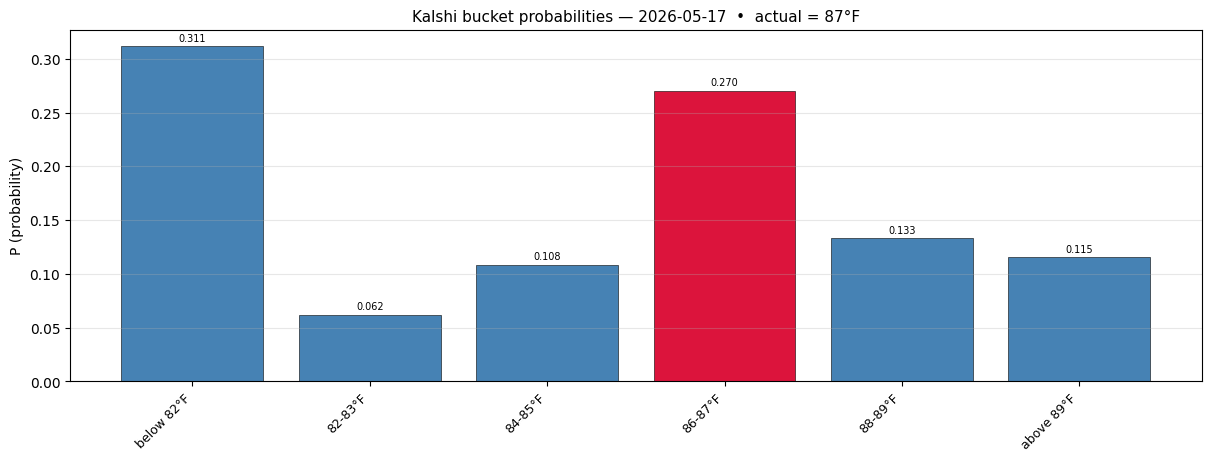

In [159]:
import re
import matplotlib.pyplot as plt


def _parse_bucket(spec):
    """Parse a bucket spec into a (predicate, description) pair.

    Accepted spec formats:
    - int X            -> "high = X°F" (exact integer)
    - (lo, hi) tuple   -> "lo <= high <= hi" (inclusive range)
    - str ">X"         -> "high > X°F"
    - str ">=X"        -> "high >= X°F"
    - str "<X"         -> "high < X°F"
    - str "<=X"        -> "high <= X°F"
    - str "lo-hi"      -> "lo <= high <= hi"
    """
    if isinstance(spec, (int, np.integer)):
        x = int(spec)
        return (lambda F, _x=x: F == _x), f"high = {x}°F"
    if isinstance(spec, tuple) and len(spec) == 2:
        lo, hi = int(spec[0]), int(spec[1])
        return (lambda F, _lo=lo, _hi=hi: _lo <= F <= _hi), f"{lo}-{hi}°F"
    if isinstance(spec, str):
        s = spec.strip()
        m = re.fullmatch(r">=\s*(-?\d+)", s)
        if m:
            t = int(m.group(1))
            return (lambda F, _t=t: F >= _t), f"high >= {t}°F"
        m = re.fullmatch(r">\s*(-?\d+)", s)
        if m:
            t = int(m.group(1))
            return (lambda F, _t=t: F > _t), f"above {t}°F"
        m = re.fullmatch(r"<=\s*(-?\d+)", s)
        if m:
            t = int(m.group(1))
            return (lambda F, _t=t: F <= _t), f"high <= {t}°F"
        m = re.fullmatch(r"<\s*(-?\d+)", s)
        if m:
            t = int(m.group(1))
            return (lambda F, _t=t: F < _t), f"below {t}°F"
        m = re.fullmatch(r"(-?\d+)\s*-\s*(-?\d+)", s)
        if m:
            lo, hi = int(m.group(1)), int(m.group(2))
            return (lambda F, _lo=lo, _hi=hi: _lo <= F <= _hi), f"{lo}-{hi}°F"
    raise ValueError(f"Cannot parse bucket spec: {spec!r}")


def predict_kalshi_buckets(date, buckets, station=STATION):
    """Calibrated probabilities for arbitrary Kalshi bucket definitions.

    Translates the per-integer PMF (from predict()) into the bucket structure
    a specific Kalshi market uses. Use this to compare model probabilities
    directly to Kalshi contract prices, where price in dollars = probability
    in [0, 1].

    Args:
    - date (str | datetime | pd.Timestamp): target date (must be in feature_df).
    - buckets (list): bucket specs in any of the formats accepted by `_parse_bucket()`.
    - station (str): ICAO code (defaults to STATION).

    Returns:
    - pd.DataFrame with columns:
        - bucket: human-readable description (e.g., "70-71°F", "below 65°F", "above 89°F")
        - P: model probability for that bucket, in [0, 1]
        - fair_price_cents: 100 * P (Kalshi contracts are priced in cents)
        - implied_odds: 1 / P (decimal odds; "fair" multiplier on a yes-side bet)

    Notes:
    - Overlapping buckets will sum to > 1. A complete non-overlapping partition
      sums to ~1.
    - If P = 0 exactly, implied_odds is inf (don't take that bet at any price).
    """
    pmf = predict(date, station)
    rows = []
    for spec in buckets:
        predicate, desc = _parse_bucket(spec)
        mask = np.array([predicate(int(f)) for f in pmf.index])
        p = float(pmf.values[mask].sum())
        rows.append({
            "bucket":           desc,
            "P":                round(p, 4),
            "fair_price_cents": round(p * 100, 2),
            "implied_odds":     float("inf") if p == 0 else round(1 / p, 2),
        })
    return pd.DataFrame(rows)


def kalshi_temp_buckets(low_threshold, high_threshold):
    """Generate the standard Kalshi temperature contract bucket structure.

    Produces: [<low_threshold, 2°F range pairs from low_threshold up through
    high_threshold, >high_threshold]. Conventions:
      - `low_threshold` is the *below-edge* and the first integer of the lowest range
      - `high_threshold` is the *above-edge* and the last integer of the highest range
      - 2°F ranges are pairs like 70-71, 72-73, ...
      - low_threshold must be EVEN; high_threshold must be ODD
        (so the pairs partition cleanly with no overlap or gap)

    Args:
    - low_threshold (int, even): edge threshold for the "below" contract.
    - high_threshold (int, odd): edge threshold for the "above" contract.

    Returns:
    - list of bucket specs that partition the integer-F line into the standard
      Kalshi-style contract structure.

    Example:
        kalshi_temp_buckets(70, 91)
        -> ['<70', '70-71', '72-73', '74-75', '76-77', '78-79', '80-81',
            '82-83', '84-85', '86-87', '88-89', '90-91', '>91']
    """
    if low_threshold % 2 != 0:
        raise ValueError(f"low_threshold must be even; got {low_threshold}")
    if high_threshold % 2 == 0:
        raise ValueError(f"high_threshold must be odd; got {high_threshold}")
    out = [f"<{low_threshold}"]
    for lo in range(low_threshold, high_threshold, 2):
        out.append(f"{lo}-{lo+1}")
    out.append(f">{high_threshold}")
    return out


def plot_kalshi_buckets(date, buckets, station=STATION, ax=None, show_actual=True, annotate=True):
    """Bar chart of Kalshi-bucket probabilities for one date.

    Args:
    - date: target date (must be in feature_df).
    - buckets: list of bucket specs (any format accepted by predict_kalshi_buckets).
    - station: ICAO code.
    - ax: existing matplotlib Axes (creates a new figure if None).
    - show_actual: if True and the actual is known, highlight that bucket in red.
    - annotate: if True, print P over each bar (>= 0.5% only, to avoid clutter).

    Returns:
    - matplotlib Axes (caller can further customize / save).
    """
    df = predict_kalshi_buckets(date, buckets, station)
    target_date = pd.Timestamp(date).normalize()

    # Find the actual outcome (if available) and which bucket contains it.
    actual = None
    if show_actual:
        actual_row = feature_df.loc[feature_df["date"] == target_date, TARGET_COL]
        if len(actual_row):
            actual = int(actual_row.iloc[0])
    actual_idx = None
    if actual is not None:
        for i, spec in enumerate(buckets):
            predicate, _ = _parse_bucket(spec)
            if predicate(actual):
                actual_idx = i
                break

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 4.5), constrained_layout=True)

    colors = ["steelblue"] * len(df)
    if actual_idx is not None:
        colors[actual_idx] = "crimson"

    bars = ax.bar(range(len(df)), df["P"].values, color=colors,
                  edgecolor="black", linewidth=0.4)
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df["bucket"], rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("P (probability)")
    ax.grid(axis="y", alpha=0.3)

    if annotate:
        for bar, p in zip(bars, df["P"].values):
            if p >= 0.005:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + max(df["P"].max() * 0.01, 0.002),
                        f"{p:.3f}", ha="center", va="bottom", fontsize=7)

    title = f"Kalshi bucket probabilities — {target_date.date()}"
    if actual is not None:
        title += f"  •  actual = {actual}°F"
    ax.set_title(title, fontsize=11)
    return ax




# -----------------------------------------------------------------------------
# Kalshi KXHIGHCHI contract layout (6 buckets, verified against live API).
#
# Per Kalshi's KXHIGHCHI series for KMDW: exactly 6 contracts per settlement day:
#   - 1 low-edge:   "< K"        (T-strike, strike_type="less",    temp < K)
#   - 4 mid pairs:  "K -- K+1"   (B-strikes at K+0.5, K+2.5, K+4.5, K+6.5)
#   - 1 high-edge:  "> K+7"      (T-strike, strike_type="greater", temp > K+7)
#
# K (the low-edge strike) varies daily -- Kalshi re-centers around their own
# daily forecast. Examples verified via API on 2026-05-19:
#   May 14:  K=62  (cool front day)
#   May 15:  K=71
#   May 17:  K=84  (warm day)
#   May 18:  K=82
#
# CAVEAT FOR LIVE TRADING: in production, do NOT generate K from the model's
# own median -- fetch the actual K from Kalshi's API per day so we're pricing
# the SAME buckets the market is. P2 task #6 will add `fetch_kalshi_strikes_for_date(date)`.
# kalshi_layout_from_median() below is ONLY for offline analysis / backtesting
# pre-Kalshi-API integration.
# -----------------------------------------------------------------------------


def kalshi_temp_buckets_6(low_strike):
    """Generate the 6-contract Kalshi KXHIGHCHI bucket layout given the low-edge strike K.

    Args:
    - low_strike (int): the K threshold. The low-edge contract is "temp < K".
      The high-edge contract is "temp > K+7". Middle 4 buckets span K..K+7.

    Returns:
    - list[str]: 6 bucket spec strings parseable by `_parse_bucket()`. Order:
      [low_edge, range1, range2, range3, range4, high_edge].

    Example:
        kalshi_temp_buckets_6(82)
        -> ["<82", "82-83", "84-85", "86-87", "88-89", ">89"]
    """
    K = int(low_strike)
    return [
        f"<{K}",
        f"{K}-{K+1}",
        f"{K+2}-{K+3}",
        f"{K+4}-{K+5}",
        f"{K+6}-{K+7}",
        f">{K+7}",
    ]


def kalshi_layout_from_median(median_F):
    """Heuristic for OFFLINE analysis: pick a low_strike K so the 4 middle 2°F pairs
    are centered on `median_F`. NOT for live trading -- in production, fetch the
    actual K from Kalshi's API so we price the same buckets the market does.

    The 4 middle pairs span integers K..K+7 (center K+3.5). Setting K = round(median_F - 3.5)
    places the model's median near the middle of the middle range.

    Args:
    - median_F (int | float): predicted median high in °F.

    Returns:
    - int: low_strike K suitable for passing to `kalshi_temp_buckets_6()`.
    """
    return int(round(median_F - 3.5))


# ---- Example: actual Kalshi 6-contract layout on the latest day ----
# This now uses kalshi_temp_buckets_6() -- the real Kalshi structure -- with K
# derived from our model's predicted median. In production this K would come
# from Kalshi's API (P2 task #6) so we price the SAME buckets the market does.

example_date   = feature_df["date"].iloc[-1]
example_pmf    = predict(example_date)
example_cdf    = example_pmf.cumsum()
example_median = int(example_pmf.index[np.searchsorted(example_cdf.values, 0.50)])
low_K          = kalshi_layout_from_median(example_median)
buckets        = kalshi_temp_buckets_6(low_K)

print(f"Kalshi 6-contract layout for {example_date.date()}")
print(f"  Model median: {example_median}°F  ->  low_strike K = {low_K}")
actual_row = feature_df.loc[feature_df["date"] == example_date, TARGET_COL]
if len(actual_row):
    print(f"  Actual cli_high: {int(actual_row.iloc[0])}°F")
print(f"  Buckets ({len(buckets)} contracts):\n")
print(predict_kalshi_buckets(example_date, buckets).to_string(index=False))

# Visualize
plot_kalshi_buckets(example_date, buckets)
plt.show()

### §10.1 — Random-day gallery

**Unit task.** Sanity-check the bucketed PMF across the year. Pick 10 random days from `feature_df`, build a Kalshi-style bucket structure centered on each day's predicted median (so the window is meaningful in winter as well as summer), and render a 5×2 grid. The actual outcome (when available) is highlighted in red.

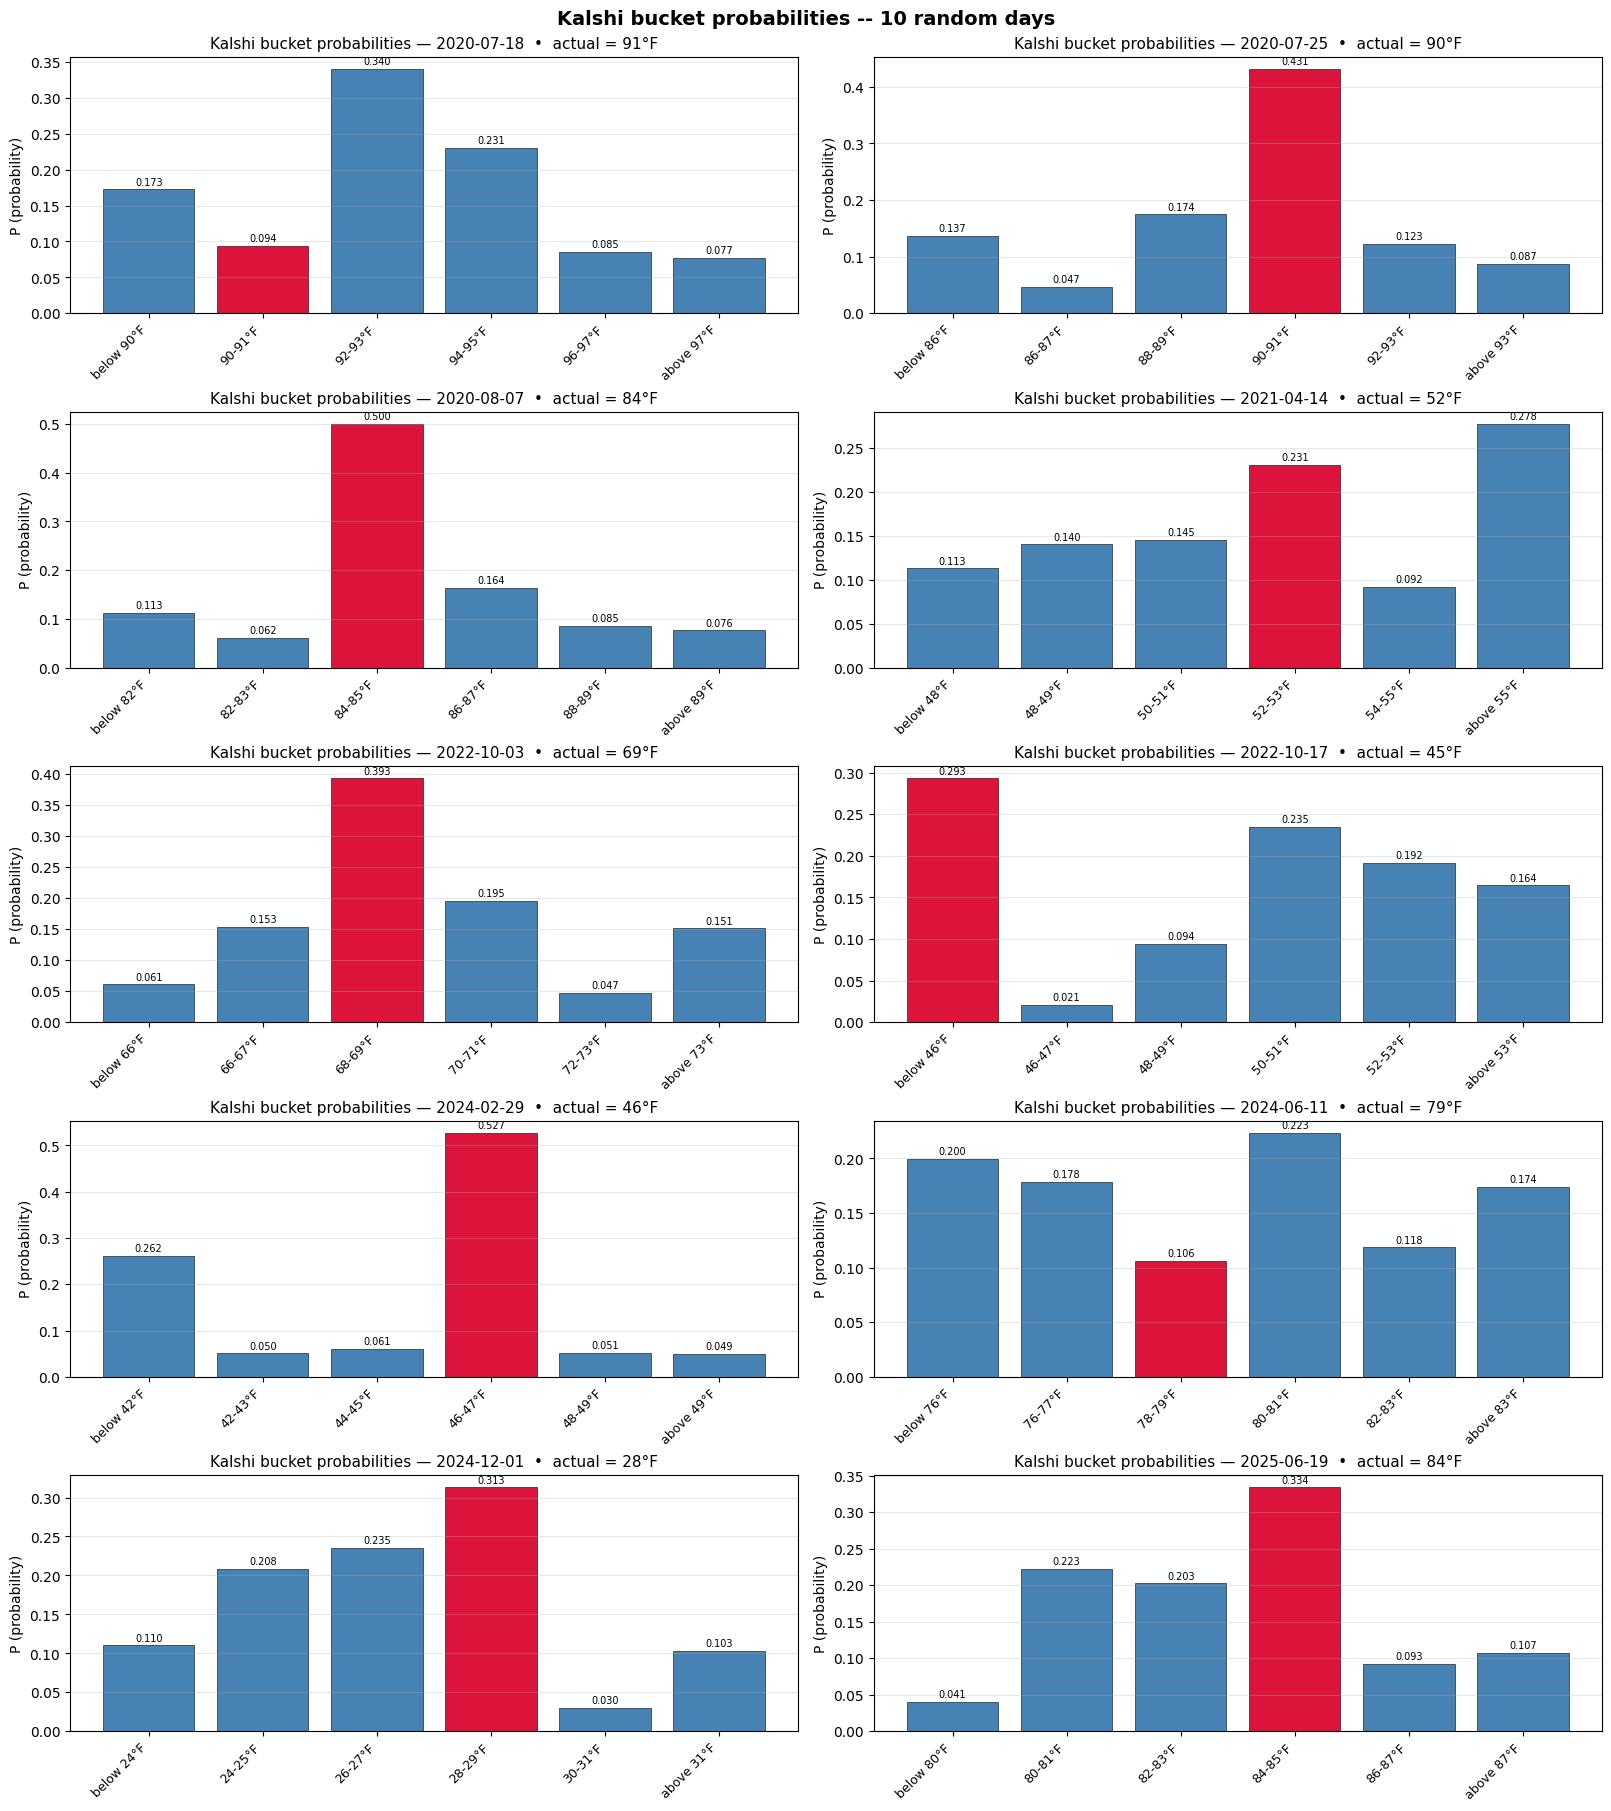

In [160]:
# Gallery of 10 random days, each with its own Kalshi-style bucket chart.
#
# Per-day bucket structure: center on the model's predicted median so the
# visible window is meaningful regardless of season. The standard Kalshi
# shape is preserved -- one "<low" edge, 2°F range pairs in the middle,
# one ">high" edge -- with `low` even and `high` odd.

import numpy as np
import matplotlib.pyplot as plt


rng = np.random.default_rng(42)
sample_dates = pd.to_datetime(
    rng.choice(feature_df["date"].values, size=10, replace=False)
)
sample_dates = sorted(sample_dates)

fig, axes = plt.subplots(5, 2, figsize=(16, 18), constrained_layout=True)
axes = axes.flatten()

for ax, d in zip(axes, sample_dates):
    pmf      = predict(d)
    cdf      = pmf.cumsum()
    median_f = int(pmf.index[np.searchsorted(cdf.values, 0.50)])
    buckets  = kalshi_temp_buckets_6(kalshi_layout_from_median(median_f))
    plot_kalshi_buckets(d, buckets, ax=ax)

fig.suptitle("Kalshi bucket probabilities -- 10 random days",
             fontsize=14, fontweight="bold")
plt.show()


### §10.2 — Bucket accuracy diagnostic

**Unit task.** A simple, market-relevant sanity check: across all OOF days, how often does the argmax 2°F bucket of the calibrated PMF contain the actual CLI high (top-1), and how often is the actual within ±1 bucket of the argmax (top-3)? Reported overall and by season.

**Caveat.** Top-1 collapses the full calibrated distribution to a single bet and discards all the information about the rest of the PMF. CRPS (§8) is the proper scoring rule we actually optimize for. Treat top-1 as a sanity check / market-intuition number, not a primary metric for model selection.

In [161]:
# Bucket-accuracy diagnostic on the calibrated OOF predictions.
#
# Bucket structure: even-low, odd-high 2°F pairs (matches the §10 Kalshi
# convention) spanning the full INTEGER_F_GRID, so the calibrated PMF
# partitions exactly into buckets with no probability mass lost.
#
# Metrics:
#   top-1: argmax bucket equals actual's bucket
#   top-3: actual is in argmax or the bucket immediately above/below
#
# Reference: DOY-climatology (empirical baseline from §7) on the same metric,
# so the model number has context (a hot/cold day at the right time of year
# already constrains the answer to a narrow band).

F_idx   = INTEGER_F_GRID.astype(int)
F_min   = int(F_idx.min())
F_max   = int(F_idx.max())
grid_lo = F_min - (F_min % 2)                     # snap to even
grid_hi = F_max if F_max % 2 == 1 else F_max + 1  # snap to odd
bucket_lows = np.arange(grid_lo, grid_hi + 1, 2)
n_buckets   = len(bucket_lows)
bucket_for_F = (F_idx - grid_lo) // 2             # int F  ->  bucket index

valid = ~np.isnan(bucket_probs_calib).any(axis=1) & ~np.isnan(actuals)
probs_eval  = bucket_probs_calib[valid]
clim_eval   = clim_probs[valid]
actual_eval = actuals[valid].astype(int)
dates_eval  = feature_df["date"].values[valid]

# Aggregate the integer PMF into 2°F buckets (vectorized via np.add.at).
def _aggregate_to_buckets(integer_probs):
    out = np.zeros((integer_probs.shape[0], n_buckets))
    np.add.at(out.T, bucket_for_F, integer_probs.T)
    return out

model_buckets = _aggregate_to_buckets(probs_eval)
clim_buckets  = _aggregate_to_buckets(clim_eval)

actual_bucket    = (actual_eval - grid_lo) // 2
model_argmax     = model_buckets.argmax(axis=1)
clim_argmax      = clim_buckets.argmax(axis=1)

model_top1 = (model_argmax == actual_bucket).mean()
model_top3 = (np.abs(model_argmax - actual_bucket) <= 1).mean()
clim_top1  = (clim_argmax  == actual_bucket).mean()
clim_top3  = (np.abs(clim_argmax  - actual_bucket) <= 1).mean()

print(f"Bucket grid: 2°F pairs from {bucket_lows[0]}-{bucket_lows[0]+1} "
      f"through {bucket_lows[-1]}-{bucket_lows[-1]+1}  ({n_buckets} buckets)")
print(f"Evaluated on {len(probs_eval)} OOF days  "
      f"({pd.Timestamp(dates_eval.min()).date()} -> "
      f"{pd.Timestamp(dates_eval.max()).date()})")
print()
print(f"{'':<30} {'Model':>10} {'DOY-Climatology':>20}")
print(f"{'Top-1 (argmax = actual)':<30} {model_top1:>10.1%} {clim_top1:>20.1%}")
print(f"{'Top-3 (within ±1 bucket)':<30} {model_top3:>10.1%} {clim_top3:>20.1%}")
print()

# By-season breakdown -- where does the model excel / struggle?
season_eval = pd.Series(dates_eval).dt.month.map(SEASON_OF_MONTH).values
print(f"{'Season':<8} {'N':>6}  {'Model top-1':>12} {'Model top-3':>12}  "
      f"{'Clim top-1':>11} {'Clim top-3':>11}")
for s in ["DJF", "MAM", "JJA", "SON"]:
    m = season_eval == s
    if m.sum() == 0:
        continue
    mt1 = (model_argmax[m] == actual_bucket[m]).mean()
    mt3 = (np.abs(model_argmax[m] - actual_bucket[m]) <= 1).mean()
    ct1 = (clim_argmax[m]  == actual_bucket[m]).mean()
    ct3 = (np.abs(clim_argmax[m]  - actual_bucket[m]) <= 1).mean()
    print(f"{s:<8} {m.sum():>6}  {mt1:>12.1%} {mt3:>12.1%}  "
          f"{ct1:>11.1%} {ct3:>11.1%}")


Bucket grid: 2°F pairs from -30--29 through 130-131  (81 buckets)
Evaluated on 1962 OOF days  (2021-01-01 -> 2026-05-17)

                                    Model      DOY-Climatology
Top-1 (argmax = actual)             19.1%                11.3%
Top-3 (within ±1 bucket)            49.5%                25.9%

Season        N   Model top-1  Model top-3   Clim top-1  Clim top-3
DJF         510         21.6%        51.2%        11.6%       25.3%
MAM         537         13.2%        40.4%         8.6%       19.6%
JJA         460         24.1%        58.5%        14.1%       33.7%
SON         455         18.2%        49.2%        11.2%       26.2%
